## Retrieval

# Advanced Retrieval Techniques in RAG

Improving the **retriever step** is the most effective way to increase the **accuracy and relevance** of a RAG system. You need a solid toolkit to build **customized, highly efficient systems**. This chapter introduces **advanced retrieval techniques** that go beyond a basic vector search.  

**Figure 701** provides an overview of techniques for **optimizing the pre-retrieval and retrieval steps**.

Real-world RAG workflows typically **combine several of these techniques**, depending on the use case. **Figure 702** shows an example workflow that combines multiple steps and advanced retrieval techniques. The workflow illustrates three key stages:

1. **Breaking down a complex query** into focused sub-queries.
2. **Routing each sub-query** to the appropriate tool or data source to retrieve relevant information.
3. **Reasoning across the different answers** to synthesize a comprehensive response.

Think of the recipes in this chapter as **building blocks** that you can combine to improve your workflow and achieve better search results. You need a **toolkit of advanced retrieval techniques** and then apply them in the way that best fits your use case.

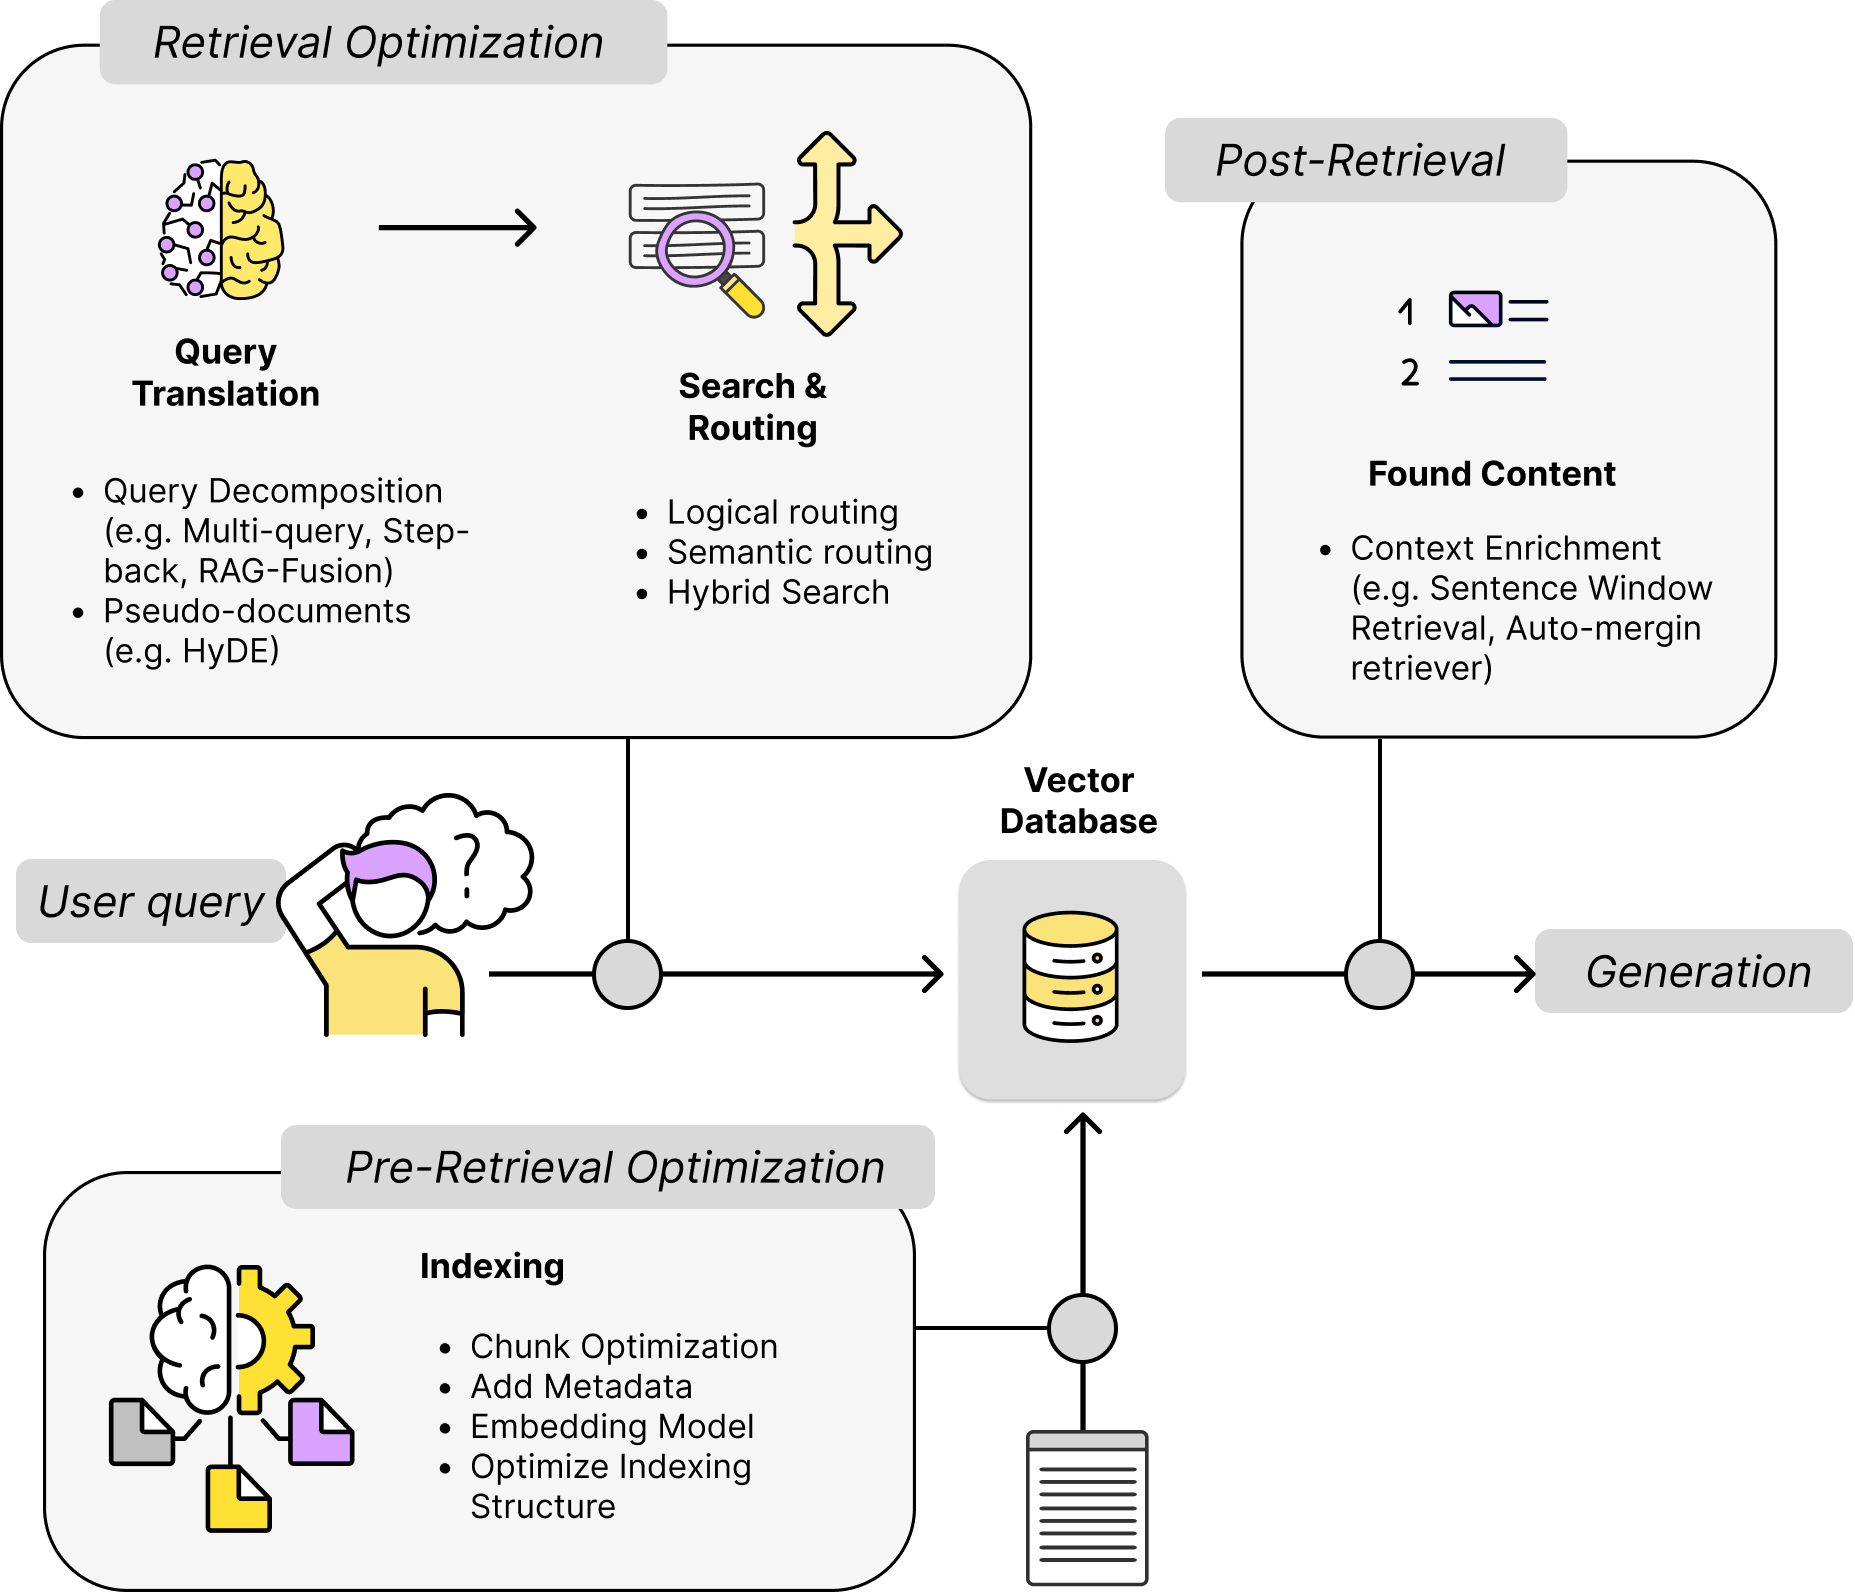

In [1]:
from IPython.display import Image, display
display(Image(filename="images/rwpc_0701.png", width=500, height=500))

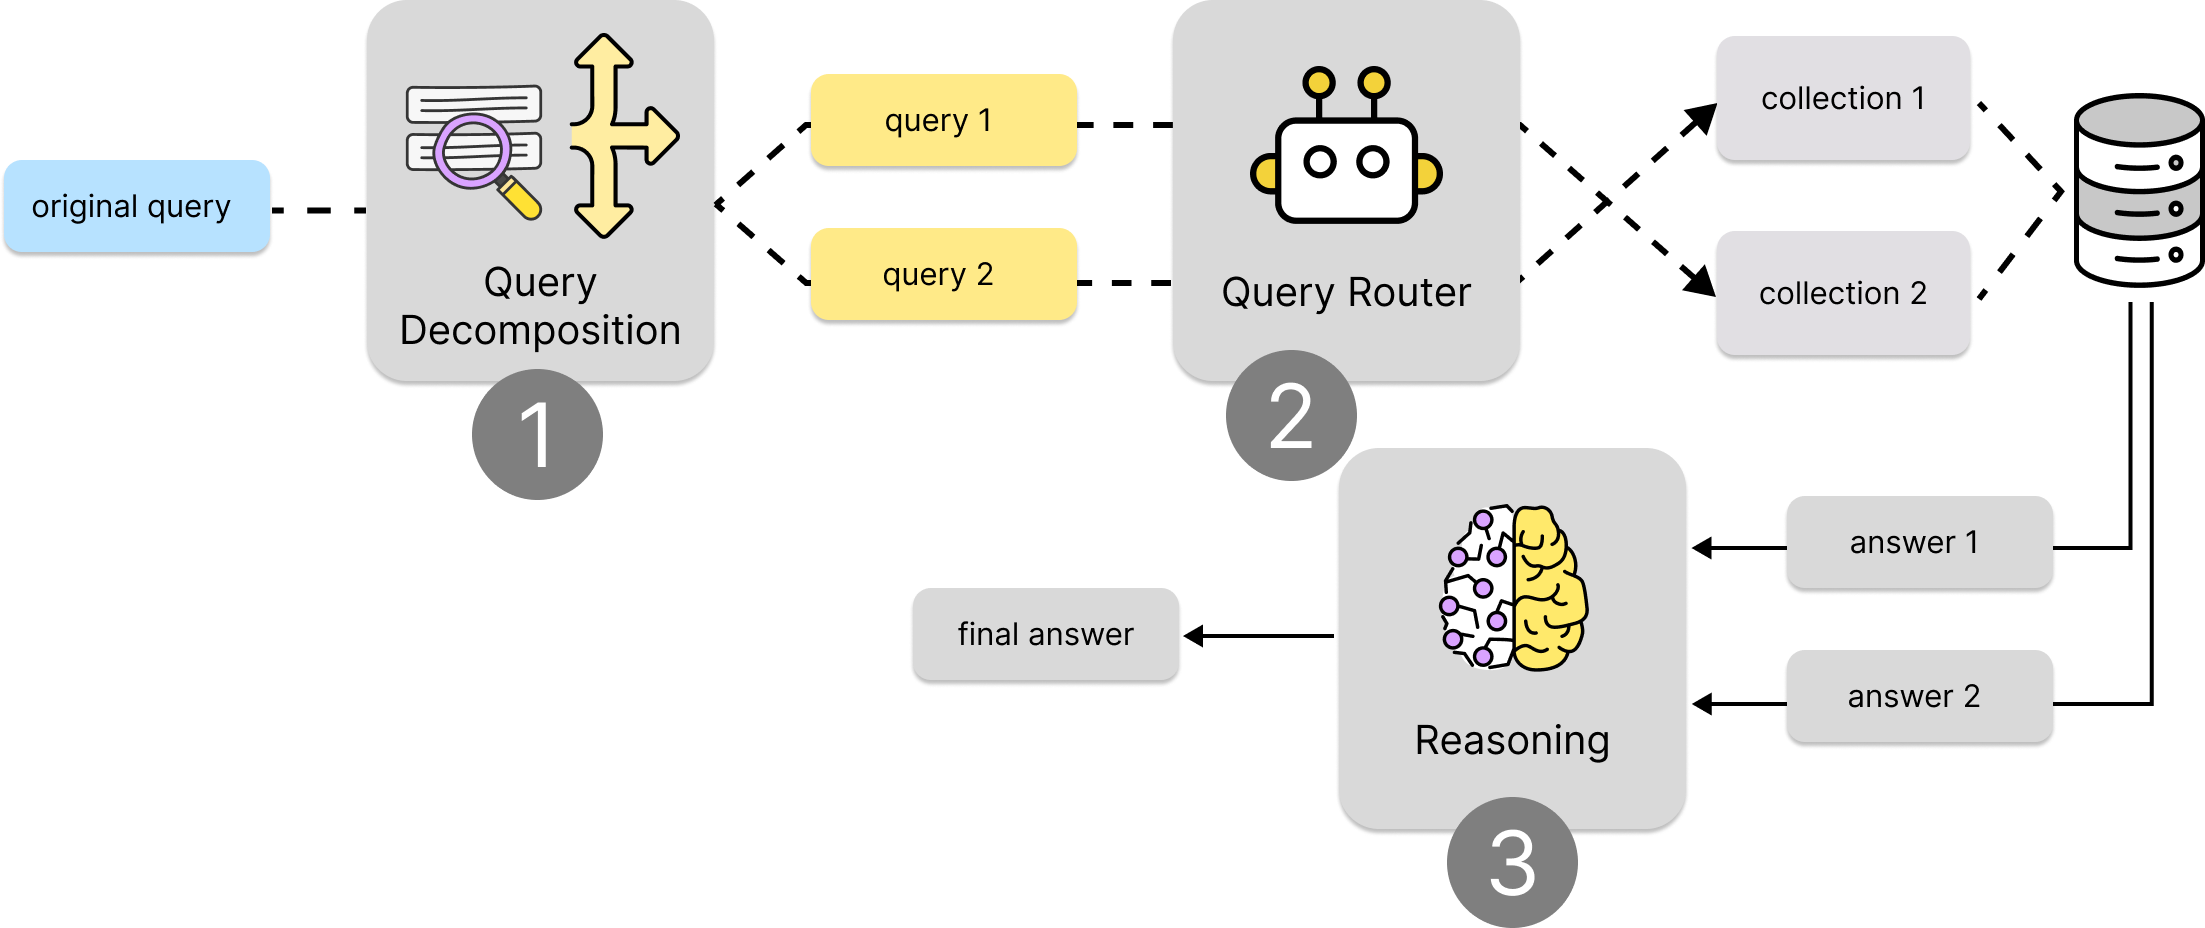

In [2]:
display(Image(filename="images/rwpc_0702.png", width=500, height=500))

# Complete Advanced Retrieval Techniques for RAG

| Technique | Description | Recipe Reference |
|-----------|-------------|-----------------|
| **Metadata Filtering** | Using metadata to filter search results based on what you know about the user | 1 |
| **Hypothetical Document Embeddings (HyDE)** | Generating hypothetical documents to improve search results | 2 |
| **Multi-Query Retrieval** | Creating multiple versions of the same prompt to find more relevant documents | 3 |
| **Query Routing System** | Using a query routing system to identify the best data sources or tools to use to answer the question | 4 |
| **Auto-Merging Retriever** | Retrieving larger, more meaningful text chunks by grouping related data | 5 |
| **Sentence Window Retrieval** | Including nearby sentences to add context to the retrieved text | 6 |
| **Query Decomposition** | Breaking down complex queries into simpler subqueries |7 |
| **Reranking** | Reviewing and evaluating the relevance of the retrieved documents using LLMs | 8 |

In [ ]:
!pip install psycopg2==2.9.10
!pip install requests==2.32.3
!pip install openai==1.82.1
!pip install python-dotenv==1.0.0

### Load sample files

This notebook uses sample Word and PDF files.

When running the notebook on Google Colab, uncomment the code below to download the `datasets` directory from the Github repo.

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !git clone --no-checkout https://github.com/polzerdo55862/RAG-with-Python-Cookbook.git
    %cd RAG-with-Python-Cookbook
    !git sparse-checkout init --cone
    !git sparse-checkout set datasets
    !git checkout
    !cp -r datasets /content/datasets
    print("\u2713 Datasets downloaded to /content/datasets")
else:
    print("\u26a0 Running locally. Using ../datasets/ directory")

⚠ Running locally. Using ../datasets/ directory


### Load secrets

If you run this code in Google Colab, save your OpenAI API key in the colab secrets and load it to the environmental variables.

In [ ]:
import os
import sys
from dotenv import load_dotenv

# Check if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        from google.colab import userdata  # type: ignore

        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
        os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
        os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
    except ModuleNotFoundError:
        pass
else:
    load_dotenv()

### 1 Optimizing Query Results using Metadata Filtering in PostgreSQL

1. Problem
You want to make search results more robust and accurate by applying metadata filters before running semantic search.

2. Solution
Storing metadata alongside embeddings lets you apply filters before semantic search. This narrows the search space to a relevant subset of your data. Imagine you’re building a chatbot for a sports website covering football, tennis, and basketball. A user query such as “Who’s the best player of all time?” is too vague. Without knowing the sport, it’s impossible to answer properly.

If you have context about the user, you can filter the vector dataset down to the relevant sport. If the user is a football enthusiast, you filter to football content only and search within that subset.

Example: Jim is a football fan from Liverpool. When he asks for the latest match results of his favorite club, user preferences likely indicate that he is looking for last night’s match results for FC Liverpool.

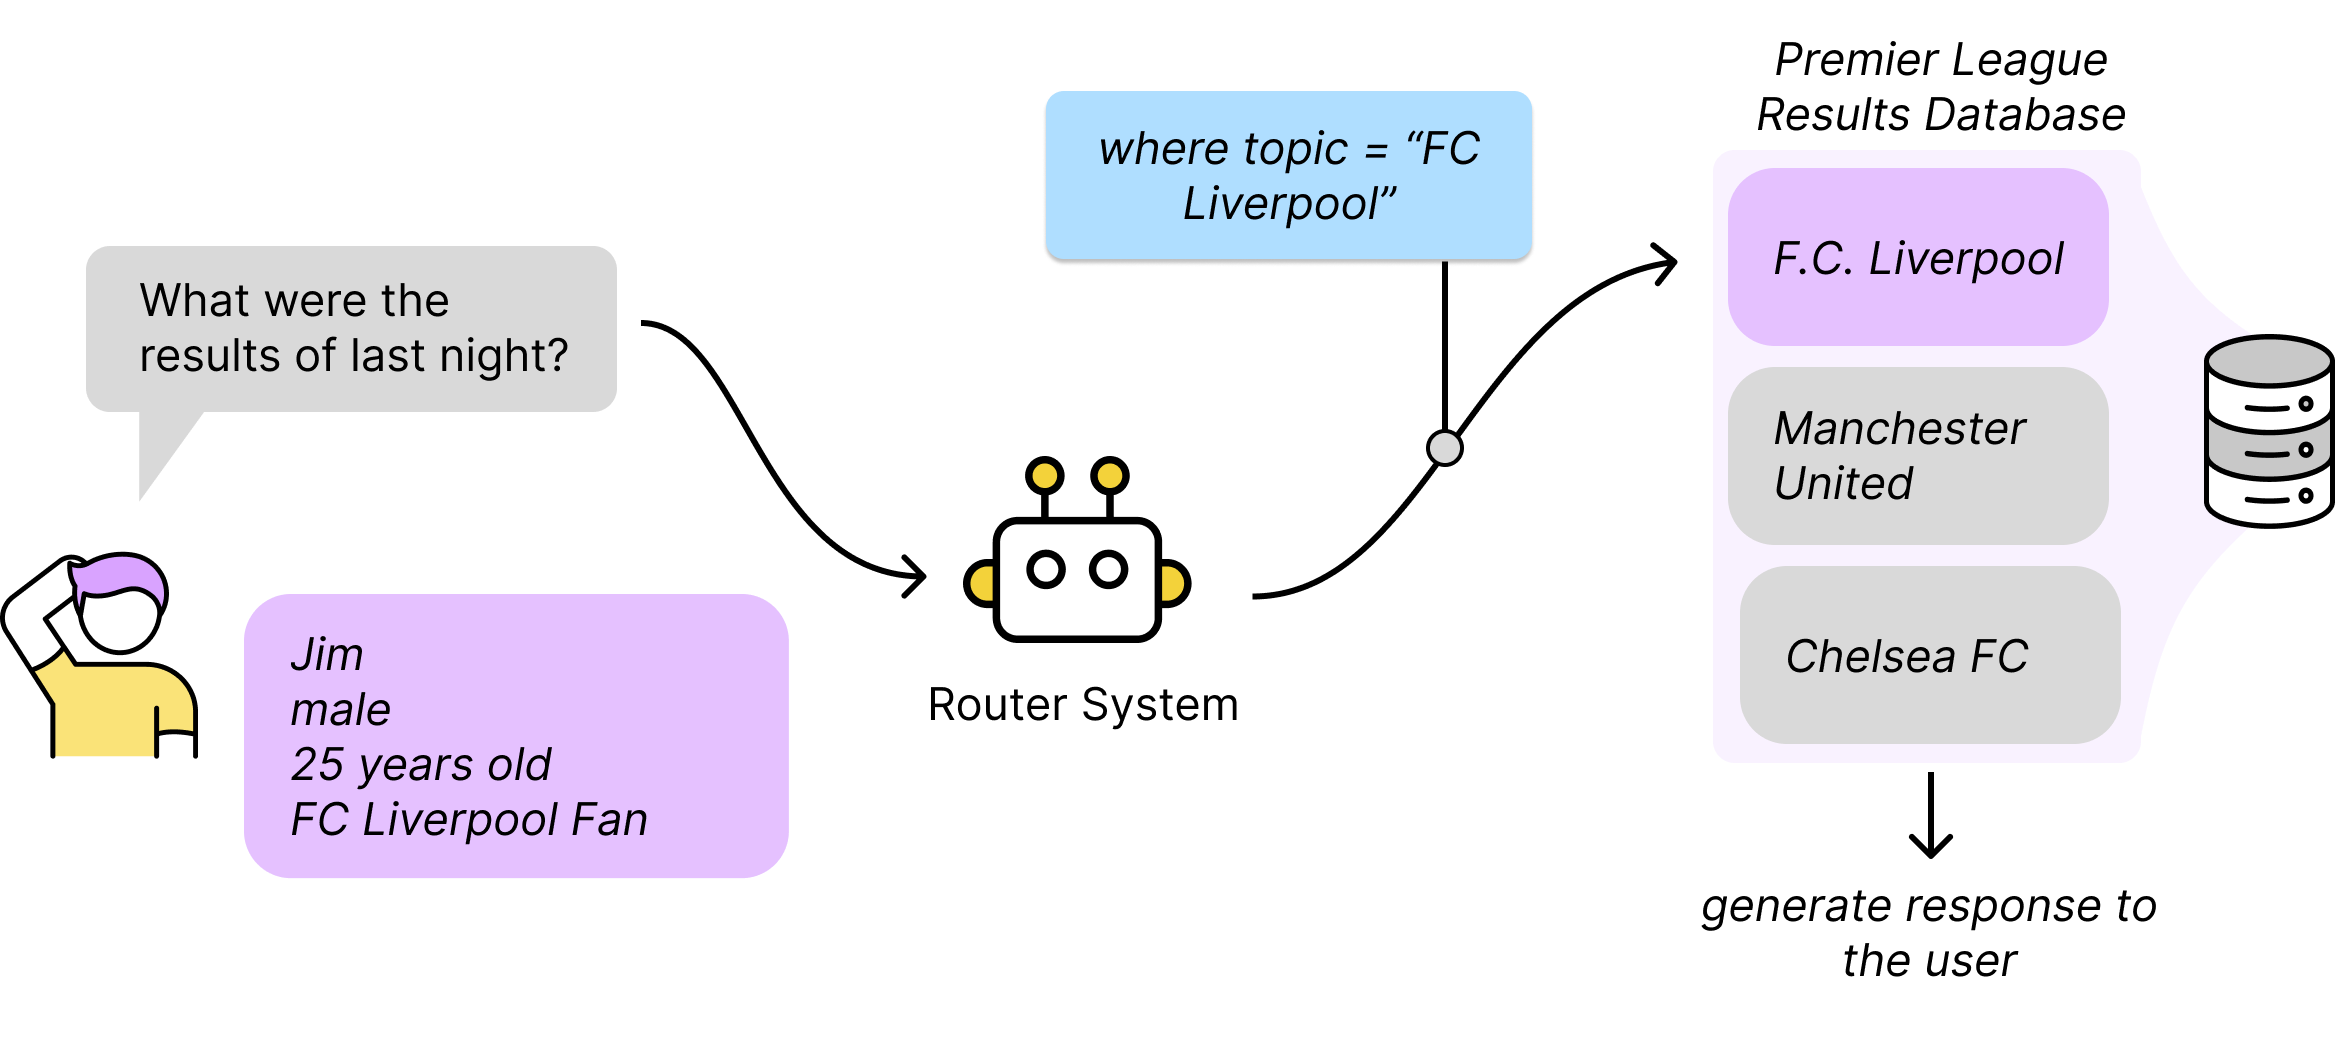

In [3]:
display(Image(filename="images/rwpc_0703.png", width=500, height=500))

1. Let’s implement this approach using PostgreSQL as the vector database. You only need the psycopg2 library to connect to Postgres and the OpenAI client to generate vector embeddings:
2. pip install psycopg2 openai

In [ ]:
# ------------------------------
# IMPORT LIBRARIES
# ------------------------------
import psycopg2
import json
from openai import OpenAI

# ------------------------------
# CONNECT TO POSTGRESQL DATABASE
# ------------------------------
conn = psycopg2.connect(
    dbname="rag_cookbook",          # Database name
    user="rag_cookbook_user",       # Username
    password="rag_cookbook_user_pw",# Password
    host="localhost",               # Host
    port="5432",                    # PostgreSQL port
)

cur = conn.cursor()

# ------------------------------
# ENABLE VECTOR EXTENSION
# ------------------------------
# pgvector extension adds native vector type and similarity operators
cur.execute("""CREATE EXTENSION IF NOT EXISTS vector""")

# ------------------------------
# CREATE TABLE WITH METADATA
# ------------------------------
# Table schema:
# - id: SERIAL PRIMARY KEY
# - text_chunk: text content to embed
# - embedding: vector of dimension 1536
# - metadata: JSONB column to store extra information (tags, user info, date, etc.)
cur.execute(
    """
    CREATE TABLE IF NOT EXISTS embeddings_table_with_metadata (
        id SERIAL PRIMARY KEY,
        text_chunk TEXT,
        embedding VECTOR(1536),
        metadata JSONB
    )
"""
)
conn.commit()

OperationalError: connection to server at "localhost" (::1), port 5432 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "localhost" (127.0.0.1), port 5432 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?


# Metadata Filtering in RAG Systems

**Concept:**  
Metadata filtering works by **narrowing the search space** before semantic search runs. This is important when your vector database contains **diverse content**, where a global search might return irrelevant matches.  

**Mechanism:**  
1. Filter by metadata first (e.g., topic, category, user segment).  
2. Run cosine similarity or other vector similarity measures **only within the filtered subset**.

---

## When to Use
- You have **distinct user segments** (e.g., logged-in users with preferences).  
- Content naturally partitions into **categories** (e.g., products by department, articles by topic).  
- Queries are **ambiguous without context** (“best player” could mean different things in different sports).

## When to Skip
- Dataset is **topically homogeneous**.  
- You **lack metadata** to filter on.  
- Overhead of maintaining metadata **exceeds accuracy gains**.

---

## Trade-Offs
- **Upfront effort** in collecting metadata vs. **ongoing retrieval accuracy**.  
- Improves testability: allows **evaluation datasets per topic** to measure performance and identify weak spots.  

**Recommendation:**  
- Start with **one category**, validate retrieval quality, then expand incrementally.  
- Focus on **collecting the right metadata**, which is often the hardest part.  

**Reference:**  
- Recipe 4.1 shows how to extract existing metadata from documents and generate new metadata using an LLM.

### 5.2 Enhancing Search Results by Extending the Original Query with Generated Pseudo-Documents

# HyDE (Hypothetical Document Embeddings) for RAG

## 1. Problem
You want to improve **search results** by creating **pseudo-documents** that match the style of real content in your database.

## 2. Solution
**HyDE** generates **hypothetical documents** that match the user's query. These documents are then used for **semantic search**.

- The hypothetical documents **do not need to be factually correct**.  
- They resemble **plausible passages** written in a style similar to real documents in your corpus.  
- This **style matching** helps the retrieval system find more relevant real documents.

---

## How HyDE Works
1. The user asks a question.  
2. The LLM generates a **hypothetical document** that could answer the query.  
3. You **embed the hypothetical document(s)** and search your **vector database**.  
4. Use the **retrieved real documents** to generate the final answer.

---

### Examples
- A **medical query** could generate a passage about **wisdom tooth removal time**.  
- A **scientific query** could generate a passage with **statistics about COVID’s mental health impact**.  

> Figure 7-6 (from the HyDE paper) visualizes these steps, showing how hypothetical documents match the style of the target corpus.

---

### Implementation Notes
- Use an **OpenAI model** to generate the hypothetical documents.  
- A **smaller, efficient model** is usually sufficient since the goal is **plausible text snippets**, not factual correctness.  
- Use **Pydantic** to define the **expected response schema** for predictable, structured output.  
- The model should return **only the hypothetical documents**, without extra text or commentary.

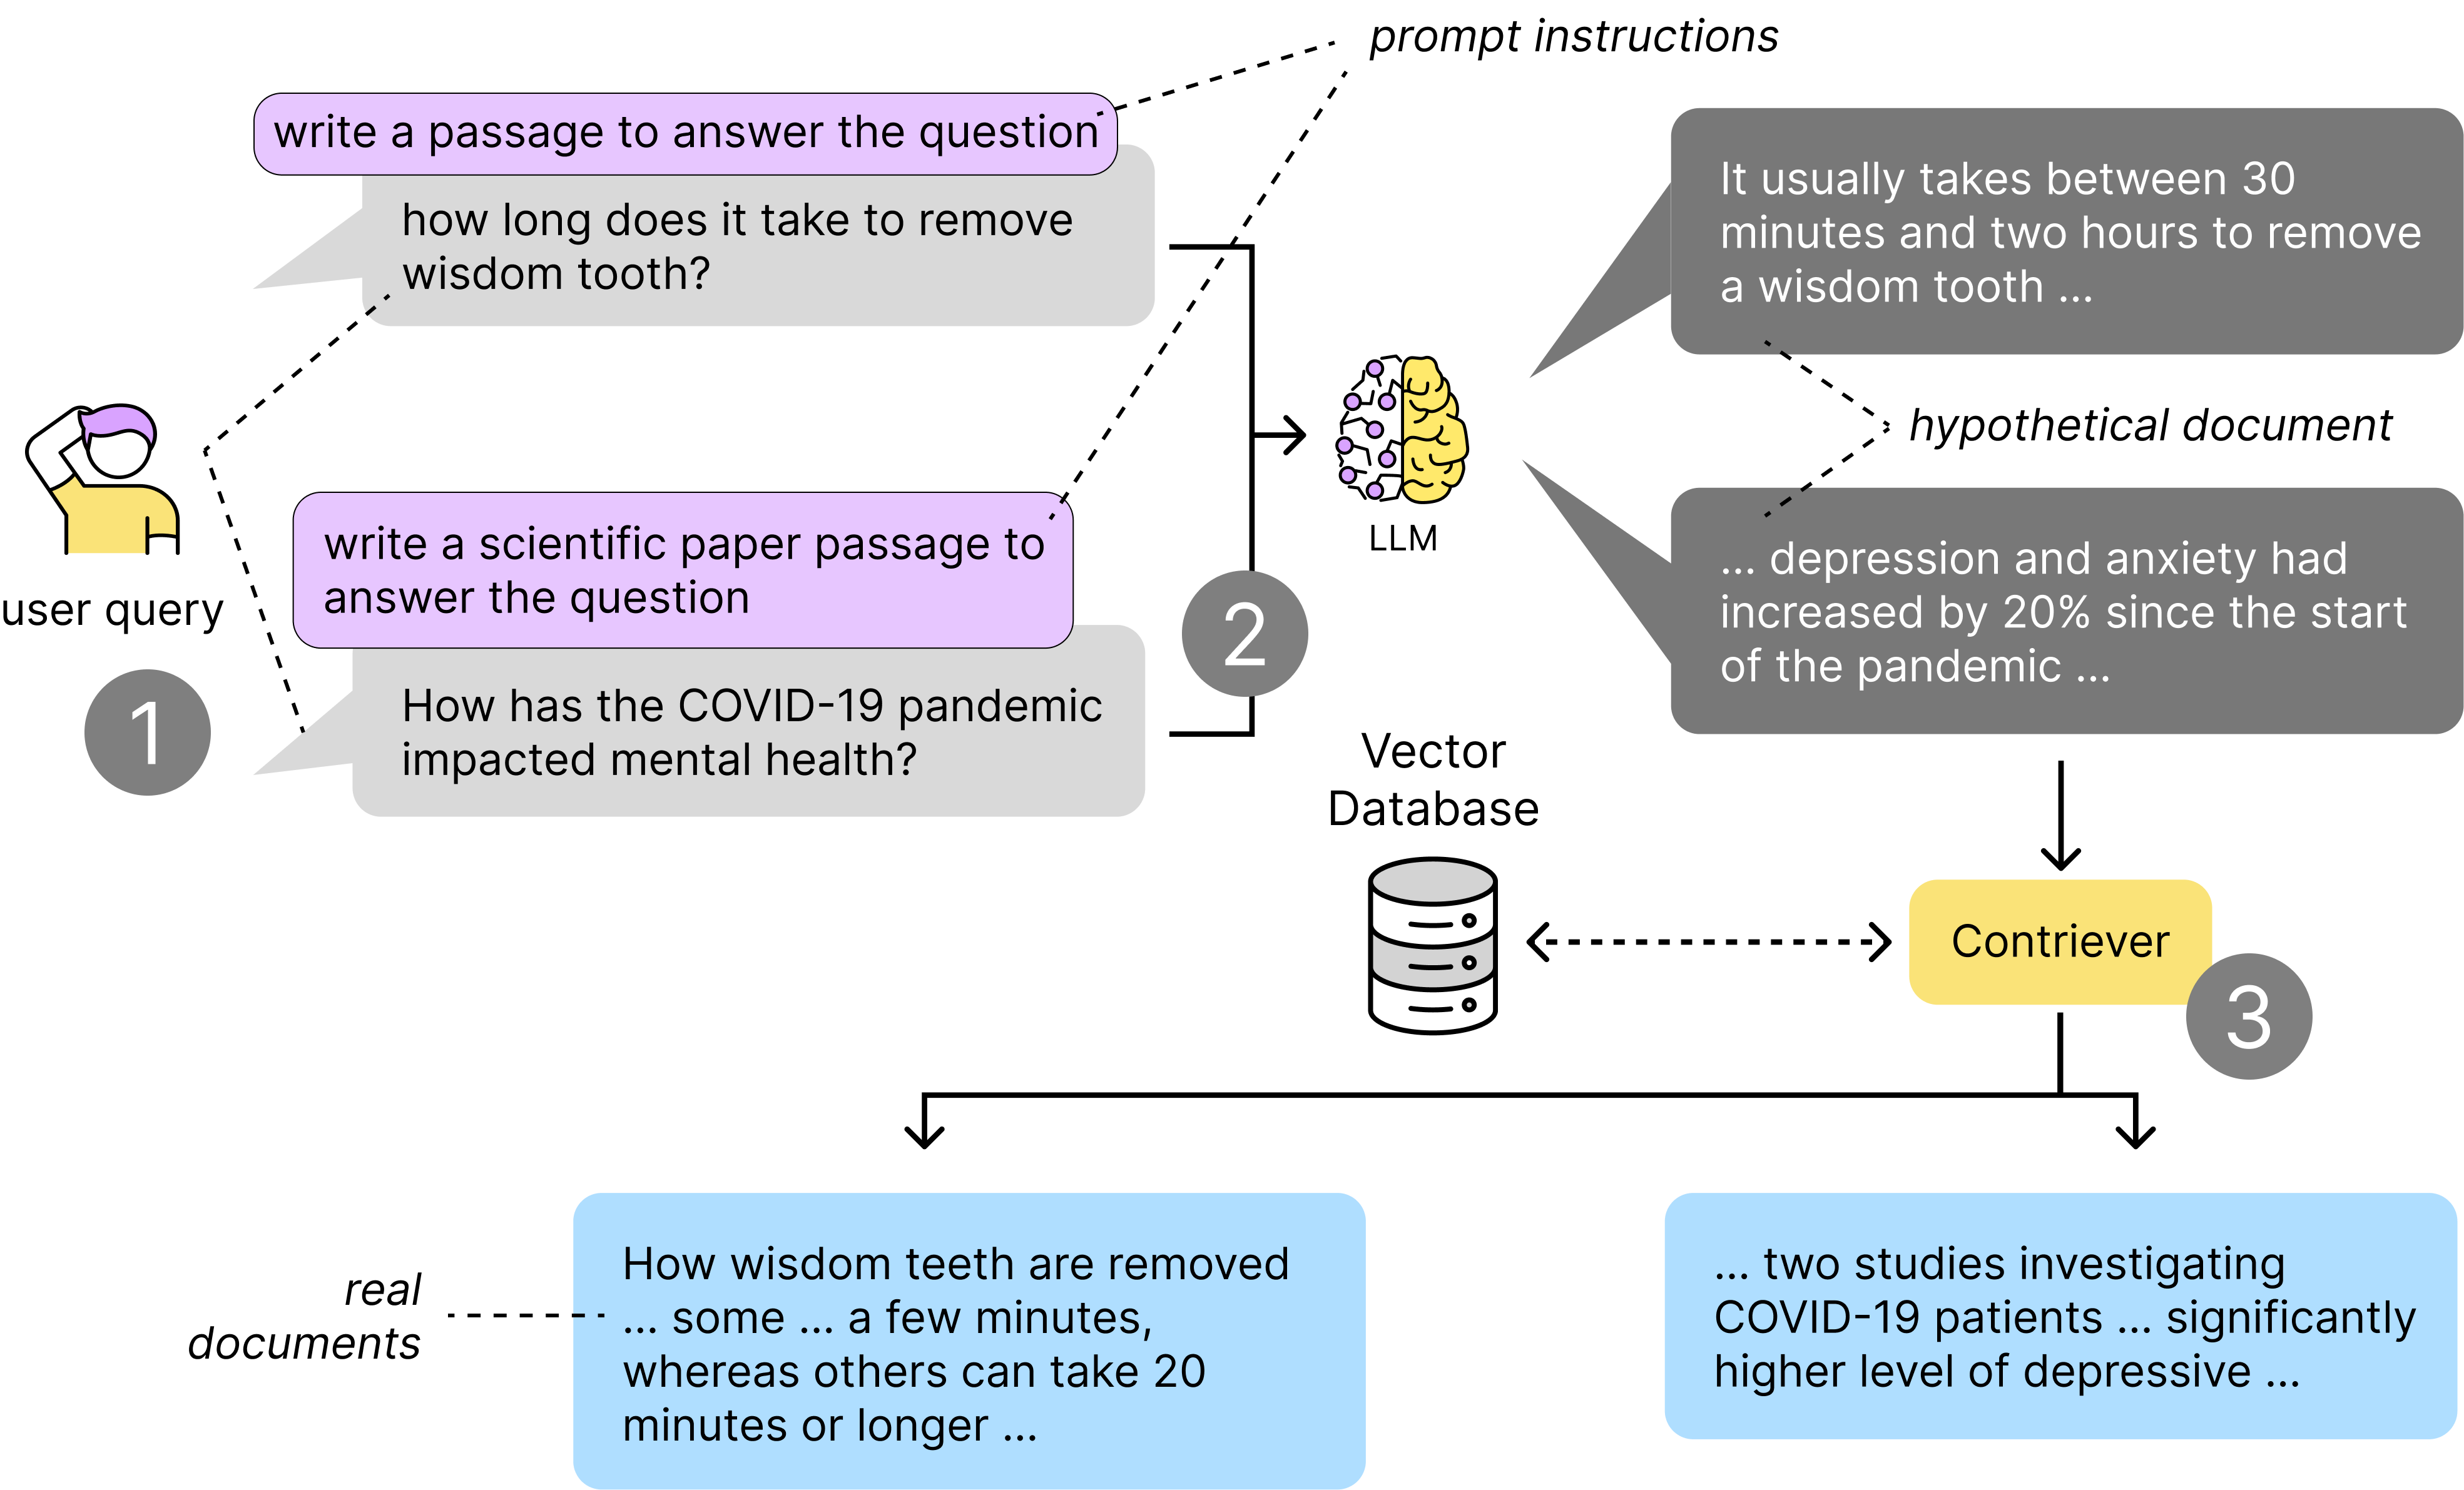

In [5]:
display(Image(filename="images/rwpc_0706.png", width=500, height=500))

In [ ]:
# ------------------------------
# DEFINE TEXT CHUNKS AND METADATA
# ------------------------------
# Each item contains:
# - text: the document or sentence
# - topic: metadata field to store in JSONB
text_chunks = [
    {"text": "Roger Federer has won 20 Grand Slam titles in tennis.", "topic": "tennis"},
    {"text": "The FIFA World Cup is the most prestigious football tournament.", "topic": "football"},
    {"text": "Serena Williams is one of the greatest tennis players of all time.", "topic": "tennis"},
    {"text": "Lionel Messi has won multiple Ballon d'Or awards in football.", "topic": "football"},
]

# ------------------------------
# INITIALIZE OPENAI CLIENT
# ------------------------------
client = OpenAI()

# ------------------------------
# INSERT TEXT CHUNKS WITH EMBEDDINGS AND METADATA
# ------------------------------
for chunk in text_chunks:
    # 1. Generate embedding using OpenAI
    response = client.embeddings.create(
        input=chunk["text"],
        model="text-embedding-3-small"
    )
    embedding = response.data[0].embedding  # 1536-dimensional vector

    # 2. Prepare metadata as JSON
    metadata = {"topic": chunk["topic"]}

    # 3. Insert into PostgreSQL table
    cur.execute(
        "INSERT INTO embeddings_table_with_metadata "
        "(text_chunk, embedding, metadata) VALUES (%s, %s, %s)",
        (chunk["text"], embedding, json.dumps(metadata)),  # JSONB column expects JSON string
    )

# Commit the transaction to save changes
conn.commit()

NameError: name 'cur' is not defined

In [ ]:
hypothetical_documents

["According to Company X's financial projections for 2024, the expected revenue is estimated to be $2 billion, reflecting a 15% growth compared to the previous year.",
 'In the Q1 2024 Earnings Report for Company X, the company reported a revenue of $500 million, and based on this quarterly trend, it is projected to reach $2.1 billion by the end of the fiscal year.',
 'Analyst forecasts for Company X suggest that with the introduction of new products and expanding market share, the total revenue for the year 2024 could potentially exceed $2.2 billion.']

# HyDE: Practical Guidance and Trade-offs

## How HyDE Works
- HyDE transforms **user queries** into text that **matches the style** of your corpus.  
- Examples:  
  - **Scientific papers** → generates formal hypothetical passages.  
  - **Casual blog posts** → generates casual hypothetical passages.  
- Embedding similarity then reflects **style + topic**, not just topic.

---

## When to Use
- There’s a **vocabulary or style mismatch** between queries and stored documents.  
  - Example: User asks *“How do I fix my car?”*, but documents say *“automotive repair procedures”*.  
- Bridges the gap between **query wording** and **corpus language**.  

---

## When to Skip
- Query and document styles already **match**.  
- **Baseline retrieval works well** (validate with evaluation metrics first).  
- **Latency or cost** of an extra LLM call per query is prohibitive.

---

## Risks and Considerations
- HyDE can generate **plausible but incorrect documents**, potentially leading to **wrong retrievals**.  
- This is more likely in **specialized domains** where the model lacks domain knowledge.  
- **Testing and validation** are essential before deploying in production.

### 5.3 Improving Search Results with Multi-Query Retrieval

# Multi-Query Retrieval in RAG

## Problem
You want to send **multiple queries** to your vector database that cover **different facets** of the original user query to ensure you retrieve all relevant content.

## Solution
**Multi-query retrieval** creates several **variations** of the original user’s question, performs **semantic search** with each one, and then **combines the results** to produce a more comprehensive answer.

---

## How It Works (Figure 7-8)
1. Take the **original query** and generate 2–3 **alternative phrasings**.  
2. **Search** the vector database with each query variant.  
3. **Merge** the documents retrieved from the different searches and send them to the LLM.

> Each query variant can surface **different relevant documents**, giving you broader coverage of the knowledge base.

---

## Example
Original user query:  
*"What are the benefits of renewable energy?"*

Derived multi-query variations:  
1. What are the **environmental benefits** of renewable energy?  
2. How does renewable energy contribute to **economic growth**?  
3. What are the **drawbacks** of renewable energy?  

> Each variant targets a **different aspect** that is likely important for generating a thorough answer.

---

## Practical Implementation
- Use an **OpenAI LLM** to generate multiple variations of the original query.  
- To ensure the output is **strictly a list of strings**, define a **Pydantic model** as the expected response schema.  
- Required libraries: `openai` SDK and `pydantic`.

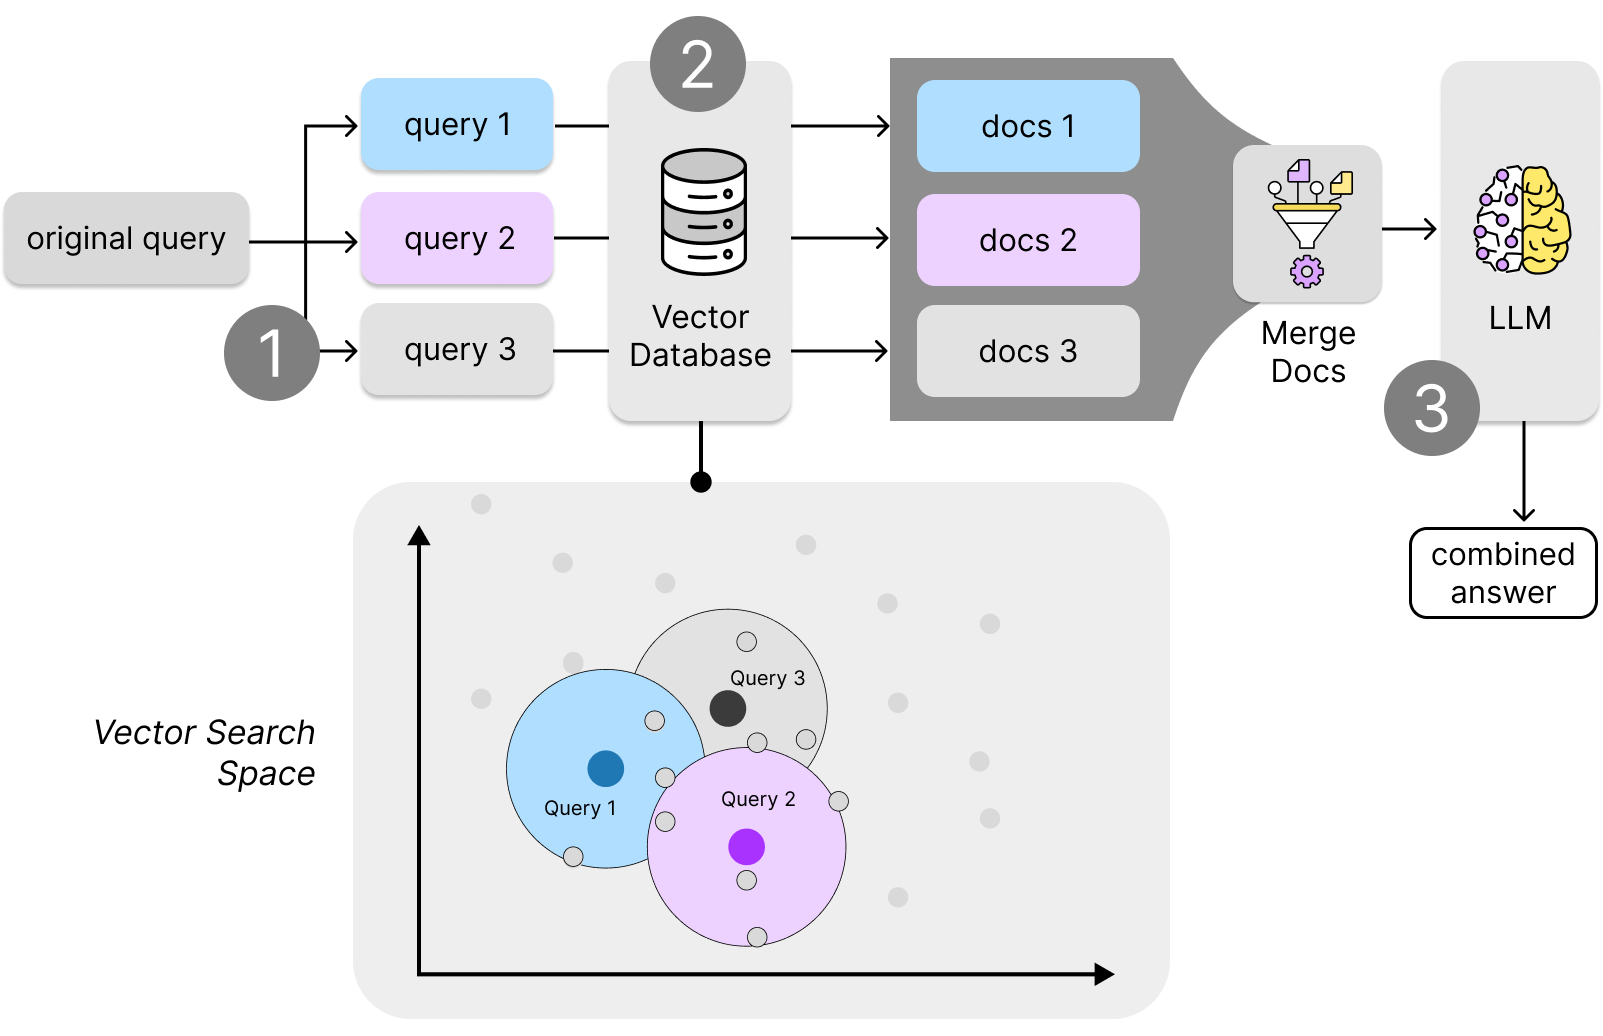

In [6]:
display(Image(filename="images/rwpc_0708.png", width=500, height=500))

In [ ]:
# ------------------------------
# IMPORT LIBRARIES
# ------------------------------
from openai import OpenAI
from pydantic import BaseModel

# ------------------------------
# INITIALIZE OPENAI CLIENT
# ------------------------------
client = OpenAI()

# ------------------------------
# DEFINE ORIGINAL USER QUERY
# ------------------------------
question = "What are the benefits of renewable energy?"

# ------------------------------
# CREATE PROMPT FOR QUERY VARIATIONS
# ------------------------------
# The goal is to generate multiple alternative phrasings
# to improve retrieval from a vector database
query_prompt = f"""You are an AI language model assistant. Your task is
to create three alternative versions of the provided user query to
enhance the retrieval of relevant documents from a vector database.
By offering diverse variations of the query, your goal is to help
mitigate the limitations of distance-based similarity search. Provide
these alternative queries, each on a new line.

Original query: {question}
"""

# ------------------------------
# DEFINE RESPONSE FORMAT USING Pydantic
# ------------------------------
class QueryVariations(BaseModel):
    queries: list[str]

# ------------------------------
# SEND PROMPT TO OPENAI
# ------------------------------
completion = client.beta.chat.completions.parse(
    model="gpt-5-mini",
    messages=[
        {
            "role": "user",
            "content": query_prompt,
        },
    ],
    response_format=QueryVariations,
)

# ------------------------------
# EXTRACT GENERATED QUERY VARIATIONS
# ------------------------------
queries = completion.choices[0].message.parsed.queries

# Display the alternative queries
queries

['How does renewable energy reduce greenhouse gas emissions and improve environmental and public health?',
 'What economic and social advantages result from adopting renewable energy technologies (for example job creation, cost savings, and energy security)?',
 'In what ways do renewable energy sources enhance grid reliability, resilience, and long-term energy independence compared with fossil fuels?']

# Multi-Query Retrieval: Practical Guidance

## How It Works
- Expands **one query into N variants**.  
- Runs **N vector searches**.  
- **Merges results** to improve recall.  
- Exploits the fact that **different phrasings surface different documents**, mitigating vocabulary mismatches.

---

## Note on Recall
- **Recall** measures how many relevant documents the retriever finds out of all relevant documents in your database.  
- High recall means your retriever **finds most useful information**, even if some irrelevant documents are included (they can be filtered later).

---

## When to Use
- User questions are **broad or ambiguous** (e.g., “renewable energy benefits” → environmental, economic, social).  
- Single queries **consistently miss relevant documents** (validated via evaluation datasets).  
- Improving recall **justifies the extra N× search cost**.

## When to Skip
- Questions are **narrow and specific**, handled well by a single query.  
- **Retrieval latency budget** cannot absorb N parallel searches + 1 LLM call.  
- **Evaluation metrics** show single-query retrieval already achieves target recall.

---

## Trade-Offs
- **Cost and latency** increase roughly **N×**: e.g., 3 queries + 1 LLM call ≈ triple retrieval time and compute cost.  
- Best suited for **complex research queries** rather than simple FAQs.

---

## Key Distinction
- **Multi-query retrieval**: generates **semantically similar variants** of the same question.  
- **Query decomposition**: breaks a **complex question into distinct sub-questions** needing separate answers.  
- **Combine both** when you have **complex multi-part questions** that also benefit from multiple phrasings per part.

### 5.4 Addressing Complex Requests by Designing a Query Routing System

# Query Routing System in RAG

## Problem
You want to handle **complex user questions** by directing them to the **right data source or tool**.

---

## Solution
A **query routing system** selects the **most suitable tool or data source** to answer a user’s query.

- Example:  
  - *User asks:* “What is 87 × 99?” → best handled by a **calculator tool**.  
  - *User asks:* “Google’s revenue in 2022?” → best handled by **vector search** over financial reports.

- In a RAG system with **multiple data sources and tools**, an **orchestrator** routes each query to the correct component.

---

## How It Works (Figure 7-10)
1. The system has access to multiple **knowledge stores** and **tools**:  
   - Financial reports (Microsoft, Google, etc.)  
   - SQL databases (e.g., historical stock prices)  
   - Specialized APIs or calculators  

2. The **router** decides which data source or tool to use based on the query.  

3. For **complex questions**, the router can:  
   - Break the task into **sub-questions**  
   - Assign each sub-question to the appropriate source/tool  
   - Merge the results into a **final answer**

---

## Practical Implementation
- Use an **LLM-based router**.  
- Prompt the LLM with the **available functions, tools, and data sources**.  
- The router outputs which function or source to query.  
- The **Python code executes the selected function**, returning the relevant results.

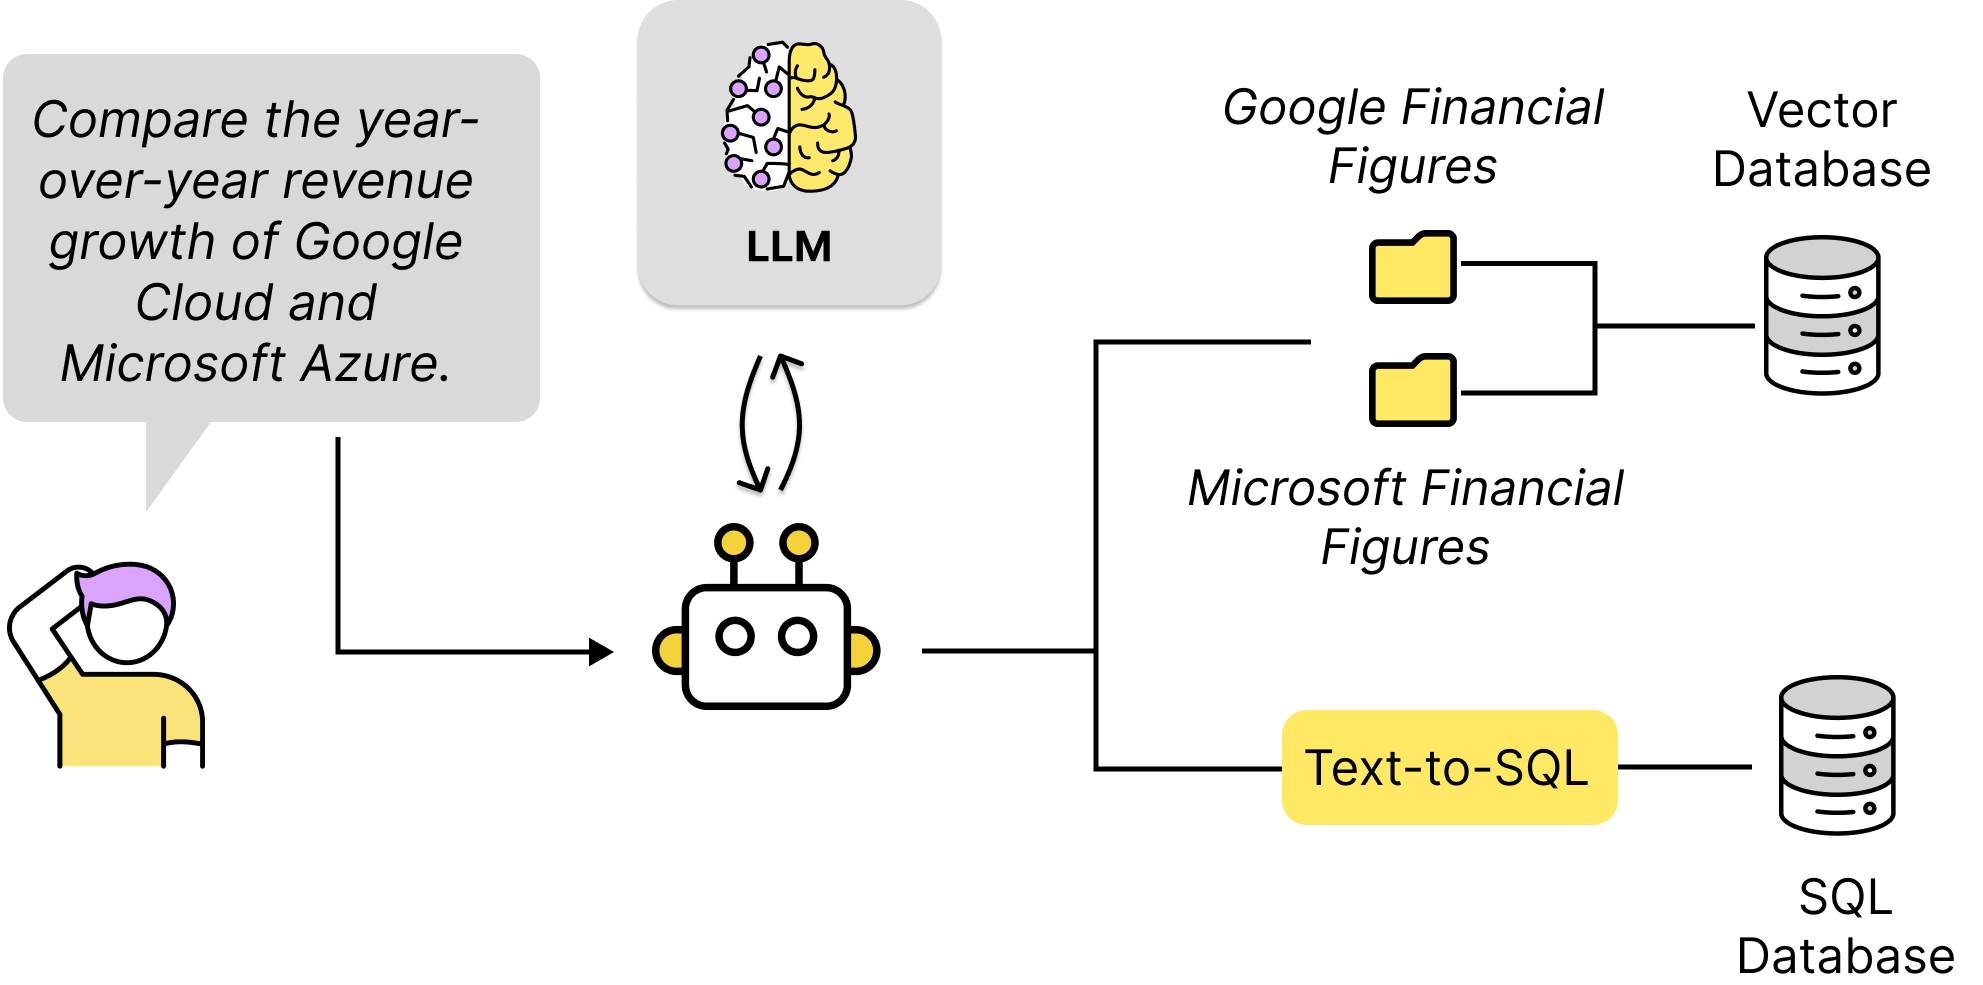

In [7]:
display(Image(filename="images/rwpc_0710.png", width=500, height=500))

# Query Routing System: Practical Guidance

## How It Works
- A **classifier** (often an LLM) selects the **best data source or tool** for each query.  
- Mechanism:  
  1. Analyze the user query.  
  2. Pick the most appropriate source (e.g., vector DB, SQL DB, API).  
  3. Execute retrieval using the selected source.  

> Example: `search_vector_db(query)` for a knowledge base, or `query_sql_db(query)` for structured data.

---

## When to Use
- Multiple **distinct data sources** exist (vector stores, SQL databases, APIs).  
- Queries clearly **map to one source**.  
- The **cost of searching the wrong source** (irrelevant results, wasted compute) exceeds routing overhead.

## When to Skip
- Single data source; faster to search everything and filter.  
- Queries are too **ambiguous** for reliable classification.

---

## Latency and Alternatives
- **LLM-based routing**: adds ~500ms–2s latency per request.  
  - Suitable for **asynchronous workflows** (batch processing, email automation).  
- **Faster alternatives**:  
  1. **Majority vote** – search all sources, pick the one with most results. Fast latency but higher compute.  
  2. **Embedding classifier** – lightweight model predicts best collection from query embeddings. Adds 10–50ms latency with minimal compute overhead.  

**Decision framework:**  
- Start with **LLM routing** to validate logic.  
- Switch to **embedding classifier** if latency is critical and collections are topically distinct.  
- Keep **LLM routing** if collections overlap heavily, as it may be the only reliable option.

---

## Key Distinction
- **Routing vs Metadata Filtering:**  
  - Routing → selects **between separate data sources** before search.  
  - Metadata filtering → narrows **results within a single source**.  
- Combine both when queries need **source selection** (routing) and **category filtering** (metadata) within that source.

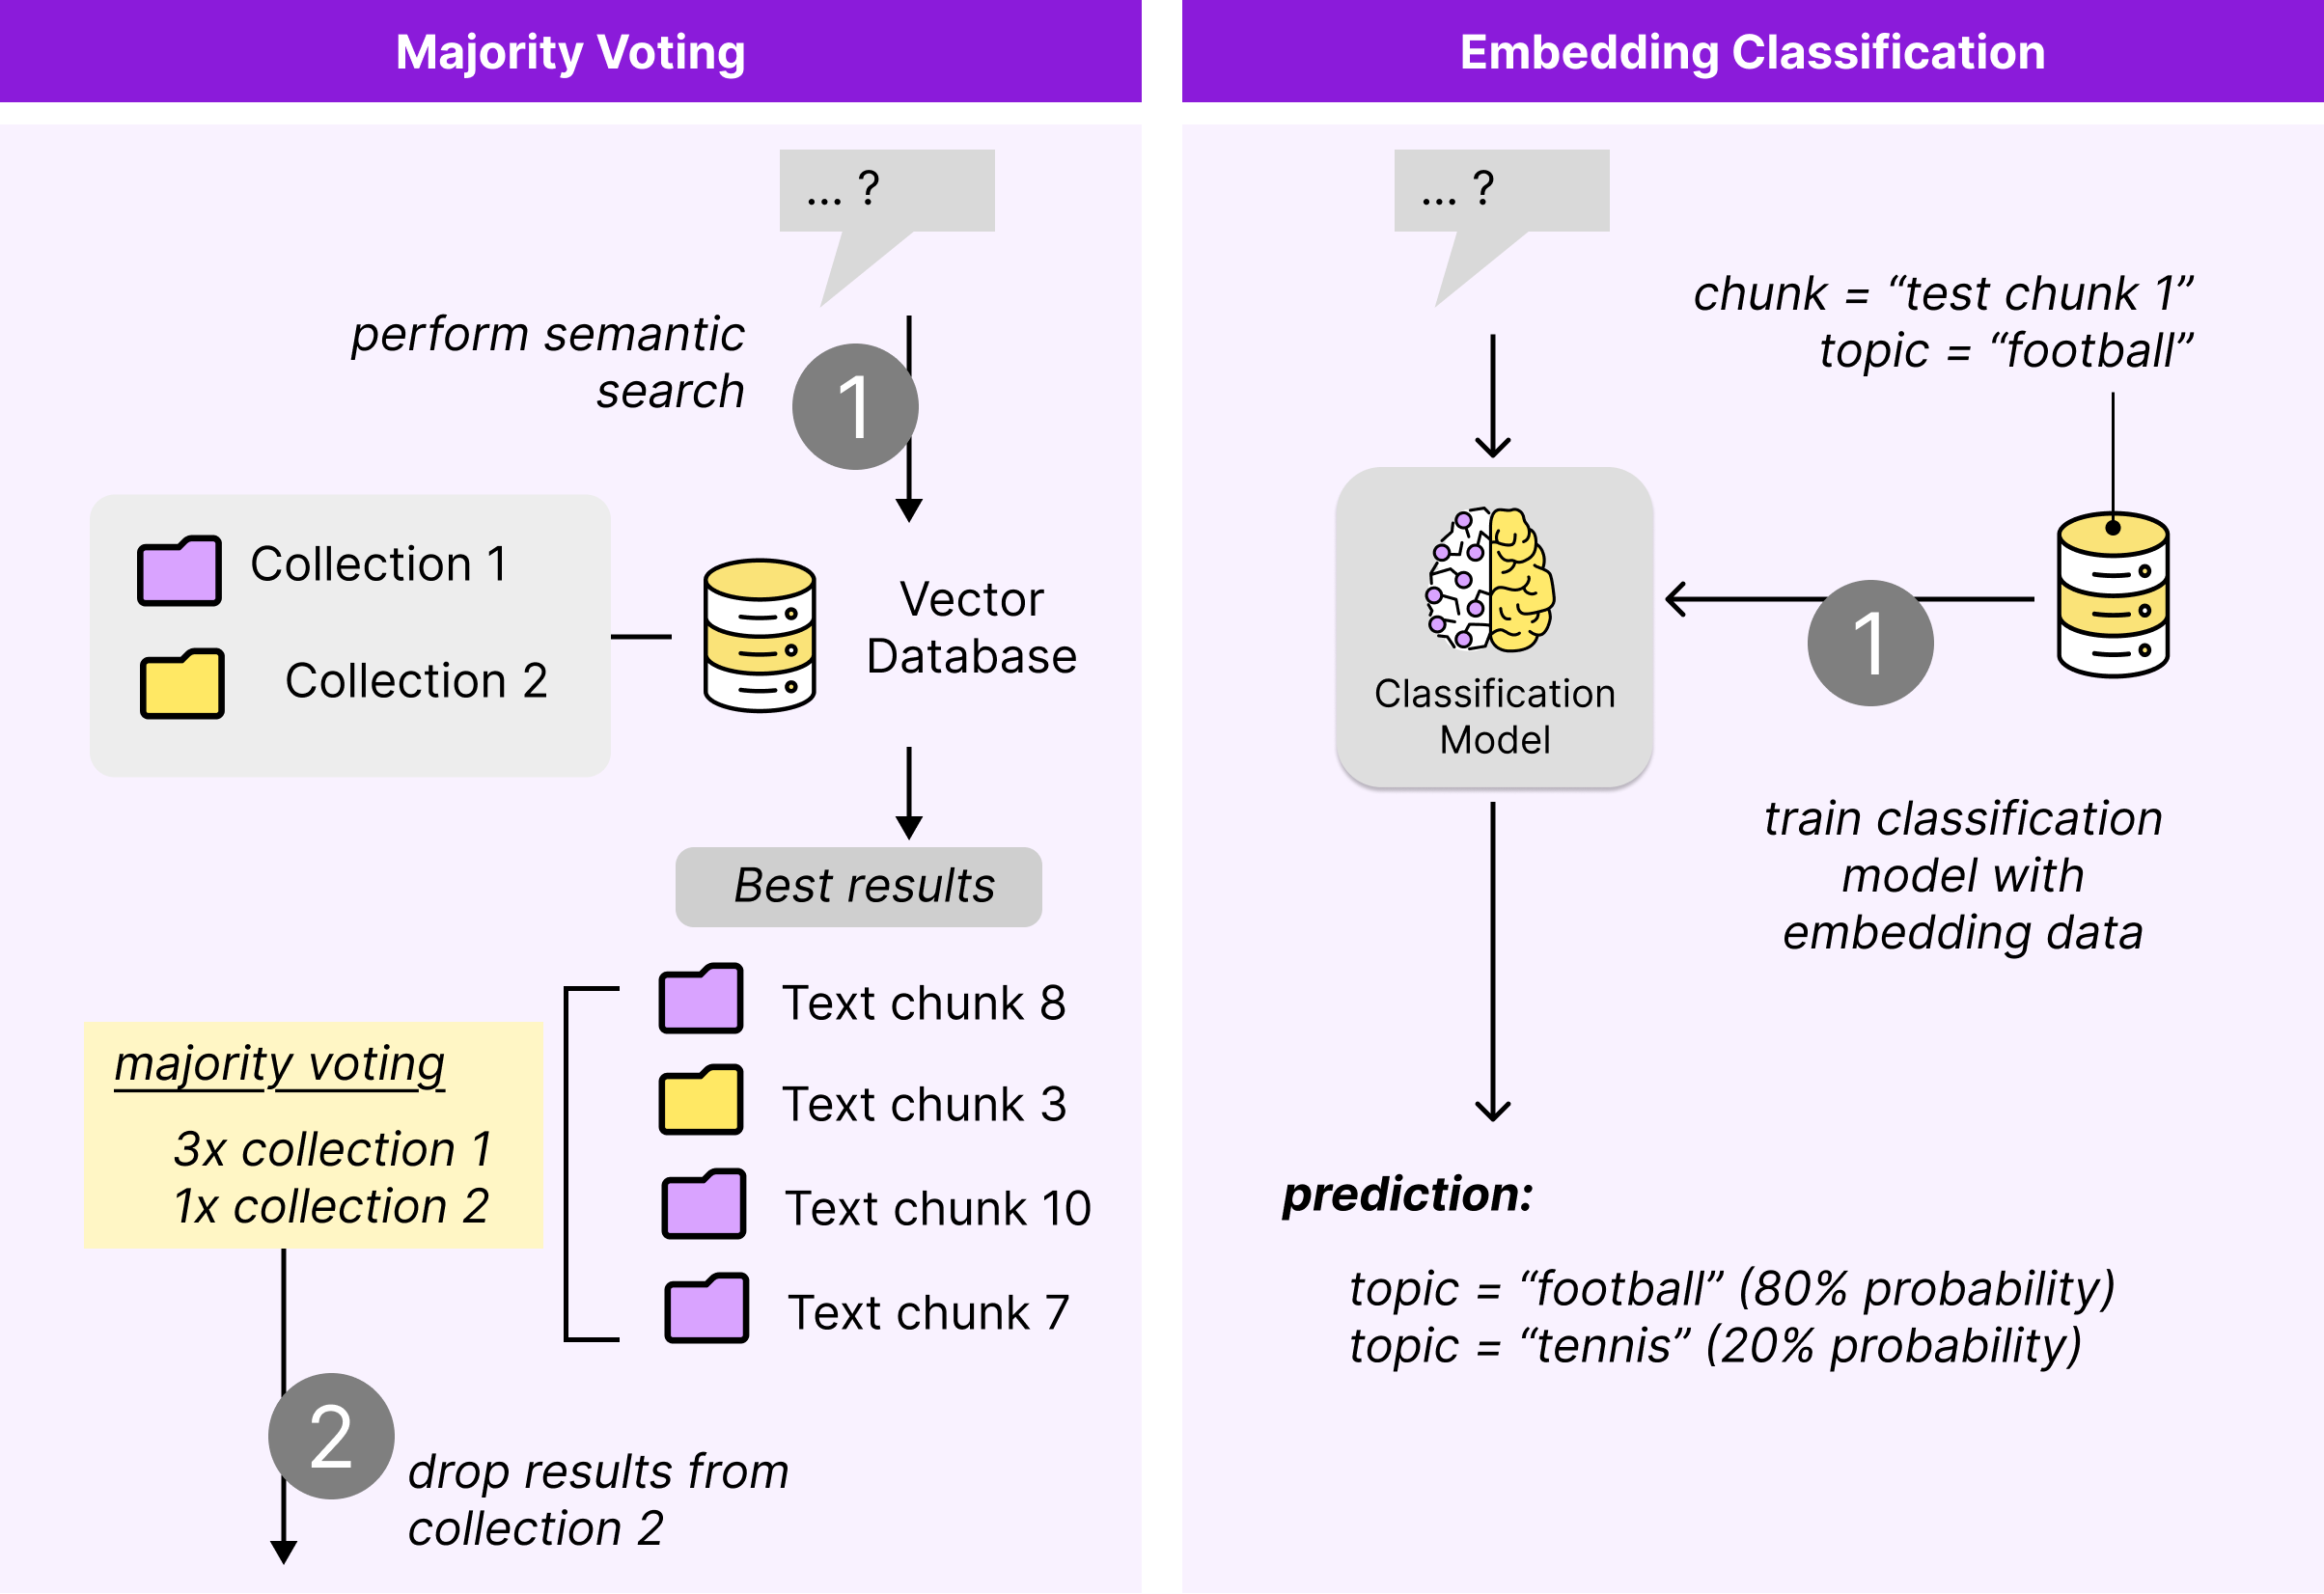

In [8]:
display(Image(filename="images/rwpc_0712.png", width=500, height=500))

Frameworks like LangChain, LlamaIndex, Amazon Bedrock Agents, and Azure AI Agent Service offer pre-built routing solutions. However, since a router is often just a well-crafted prompt, consider whether you need the additional complexity before adding framework dependencies.

In [ ]:
# ------------------------------
# DEFINE QUERY
# ------------------------------
query = "Who is the best player?"

# ------------------------------
# GET EMBEDDING FOR QUERY
# ------------------------------
# Using OpenAI embeddings (1536-dimensional)
response = client.embeddings.create(
    input=query,
    model="text-embedding-3-small"
)
query_embedding = response.data[0].embedding

# ------------------------------
# DEFINE METADATA FILTER
# ------------------------------
# Only consider rows where topic is 'football'
topic_filter = "football"

# ------------------------------
# EXECUTE POSTGRESQL QUERY WITH VECTOR SIMILARITY + METADATA FILTER
# ------------------------------
# Steps:
# 1. Filter rows using JSONB metadata column
#    WHERE metadata->>'topic' = 'football'
# 2. Compute similarity: 1 - cosine distance (embedding <=> query_embedding)
# 3. Order by similarity descending (most similar first)
# 4. Limit to top 5 results
cur.execute(
    f"""
    SELECT text_chunk, 1 - (embedding <=> %s::vector) AS similarity
    FROM embeddings_table_with_metadata
    WHERE metadata->>'topic' = %s
    ORDER BY similarity DESC
    LIMIT 5
    """,
    (query_embedding, topic_filter),  # pass parameters safely
)

# ------------------------------
# FETCH RESULTS
# ------------------------------
results = cur.fetchall()

# Display top 5 relevant results for the query
results

NameError: name 'cur' is not defined

### 5.5 Increasing Search Efficiency by Designing an Auto-Merging Retriever (aka Parent Document Retriever)

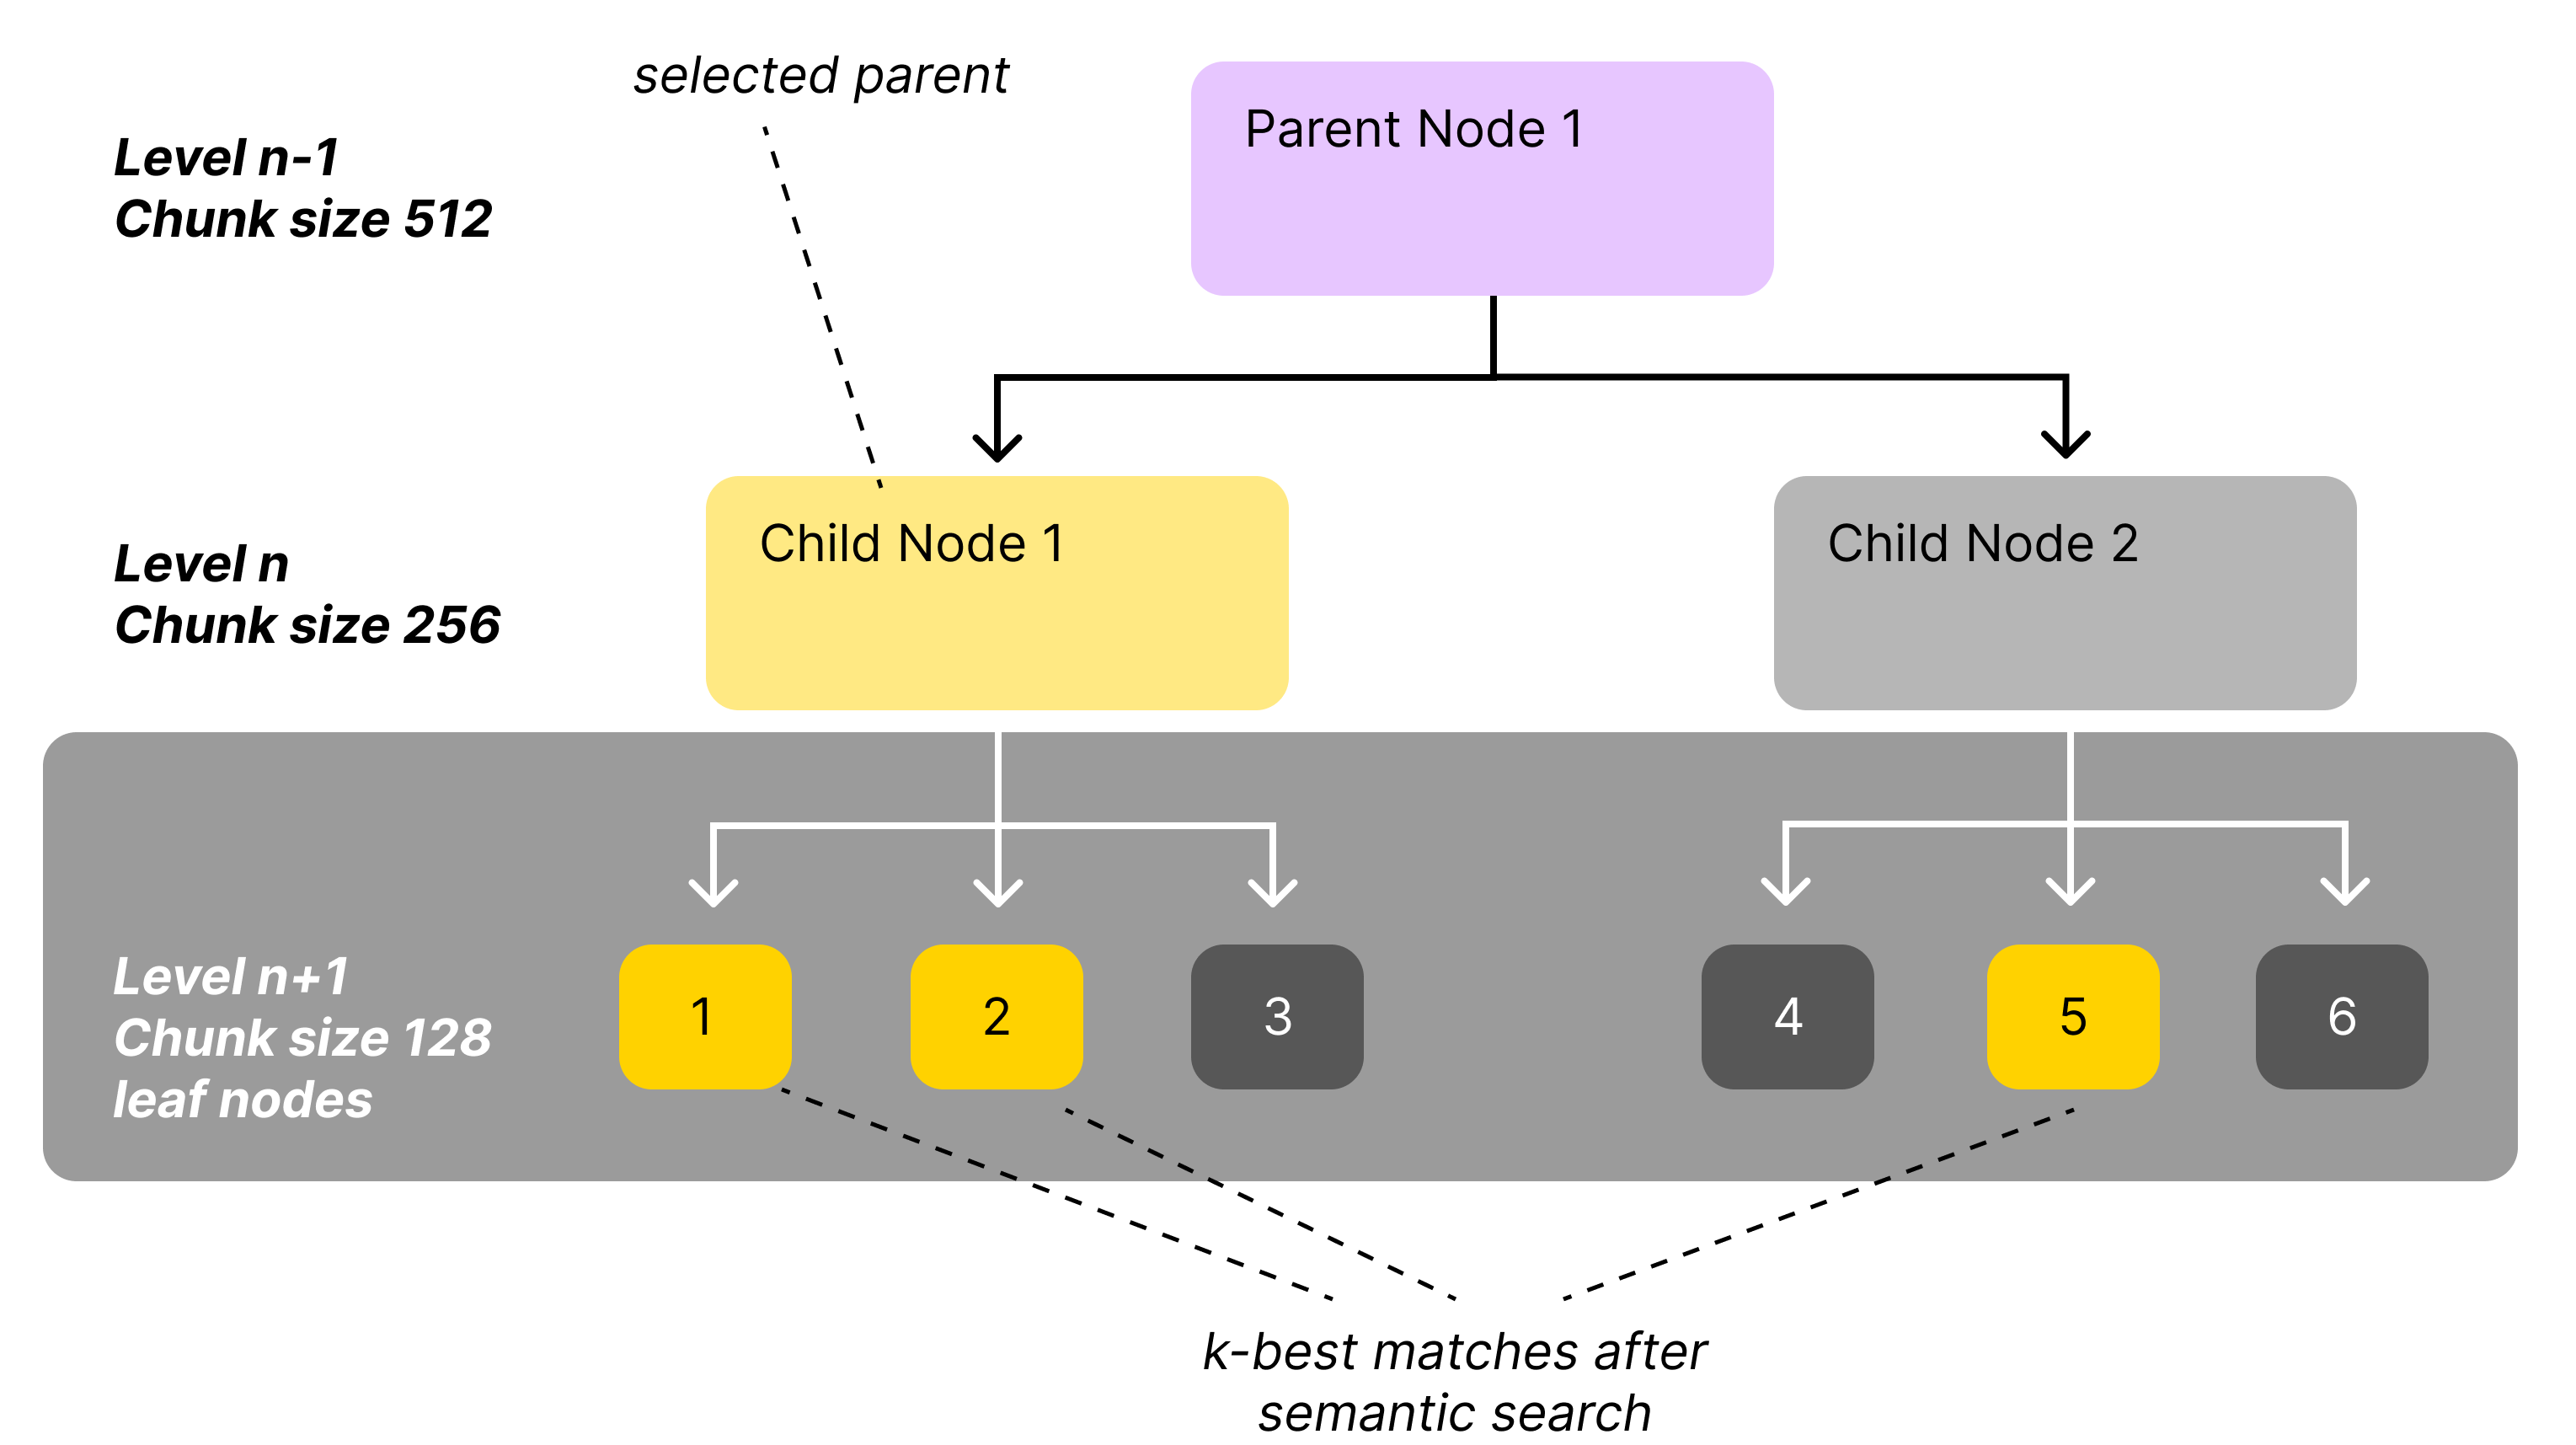

In [9]:
display(Image(filename="images/rwpc_0713.png", width=500, height=500))

# Auto-Merging Retriever in RAG

## Problem
You want to **optimize retrieval and generation** by:  
- Using **small text chunks** for semantic search to capture fine-grained information.  
- Providing **larger parent chunks** to the LLM for better context during generation.

---

## Solution
- **Organize text into child and parent chunks**:  
  - **Child chunks** → small, focused units used for **vector search**.  
  - **Parent chunks** → larger sections used for **LLM generation**.  

- **Retrieval process**:  
  1. Perform vector search on **child chunks**.  
  2. Count how many child chunks from the same parent are **relevant**.  
  3. If a **threshold** is reached, provide the **entire parent chunk** to the LLM.  

> This ensures the LLM gets **broader context** without performing search on large chunks, optimizing both retrieval and generation.

---

## Example (Figure 7-13)
- Tree structure:  
  - **Parent nodes** at the top  
  - **Child nodes** in the middle  
  - **Leaf nodes** at the bottom  

- Semantic search occurs on **leaf nodes**.  
- Retrieval merges relevant nodes:  
  - If leaf nodes 1, 2, and 5 are relevant:  
    - Two belong to **child node 1** → retrieve **entire child node 1**.  
    - One belongs to **child node 2** → retrieve **only leaf node 5**.  

> This balances **precise search** with **rich context** for the LLM.

In [ ]:
# ------------------------------
# IMPORT LIBRARIES
# ------------------------------
from pydantic import BaseModel
from openai import OpenAI

# ------------------------------
# DEFINE USER QUERY
# ------------------------------
user_query = "What is the revenue of Company X in 2024?"

# ------------------------------
# INITIALIZE OPENAI CLIENT
# ------------------------------
client = OpenAI()

# ------------------------------
# DEFINE RESPONSE FORMAT USING Pydantic
# ------------------------------
# Ensures the output is structured as a list of documents
class HypotheticalDocuments(BaseModel):
    documents: list[str]

# ------------------------------
# CREATE PROMPT
# ------------------------------
# Task: Generate three hypothetical text chunks that could answer the query
prompt = f"""
You are an AI assistant. Based on the user query below, generate
three hypothetical text chunks that contain relevant information to
answer the query.
"""

# ------------------------------
# SEND PROMPT TO OPENAI
# ------------------------------
completion = client.beta.chat.completions.parse(
    messages=[
        {"role": "system", "content": prompt},  # instruction to the AI
        {"role": "user", "content": user_query}, # user query to base documents on
    ],
    model="gpt-5-mini",
    response_format=HypotheticalDocuments,  # enforce structured list output
)

# ------------------------------
# EXTRACT GENERATED HYPOTHETICAL DOCUMENTS
# ------------------------------
hypothetical_documents = completion.choices[0].message.parsed.documents

# Display the generated hypothetical documents
hypothetical_documents

['Company X — Press Release (February 15, 2025): "For the fiscal year 2024 (January 1–December 31, 2024), Company X reported total revenue of $2,345,000,000, a 12.5% increase versus fiscal 2023. The reported figure is on a GAAP basis and includes revenues from both product sales and services; all amounts are in USD."',
 'Company X — 2024 Annual Report, Management Discussion & Analysis: "Consolidated revenue for the year ended December 31, 2024 was $2,342,850,000. Revenue by segment: Products $1,450,000,000; Services $892,850,000. The company closed the year with net new bookings and noted $4.0 million of one-time adjustments included in reported revenue."',
 'Equity Research Note — GlobalBank (January 2025): "Consensus and post-close reconciliation indicate Company X\'s 2024 revenue is approximately $2.34 billion (company-reported $2.345B; adjusted for one-time items, estimated $2.30B). Analysts expect continued mid-teens revenue growth to persist into 2025."']

### 5.6 Increasing Search Results by Designing a Sentence Window Retriever

# Sentence Window Retrieval in RAG

## Problem
You want to use **small text chunks** for semantic search, but also provide enough **surrounding context** to the LLM, so it doesn’t miss important information around the retrieved sentences.

---

## Solution
- A **sentence window retriever** adds a few sentences **before and after** the most relevant chunk to give additional context.  
- This ensures that the LLM sees the **broader context**, improving the quality of the generated answer.

---

## Example (Figure 7-14)
- **User query:** “Tell me about FC Bayern Munich.”  
- **Semantic search result:** A paragraph about recent successes and titles.  
- **Problem:** May miss historical context (club origins, meaning of the name, location).  
- **Sentence window retriever:** Includes surrounding sentences to provide **full context** to the LLM, improving comprehension and response quality.

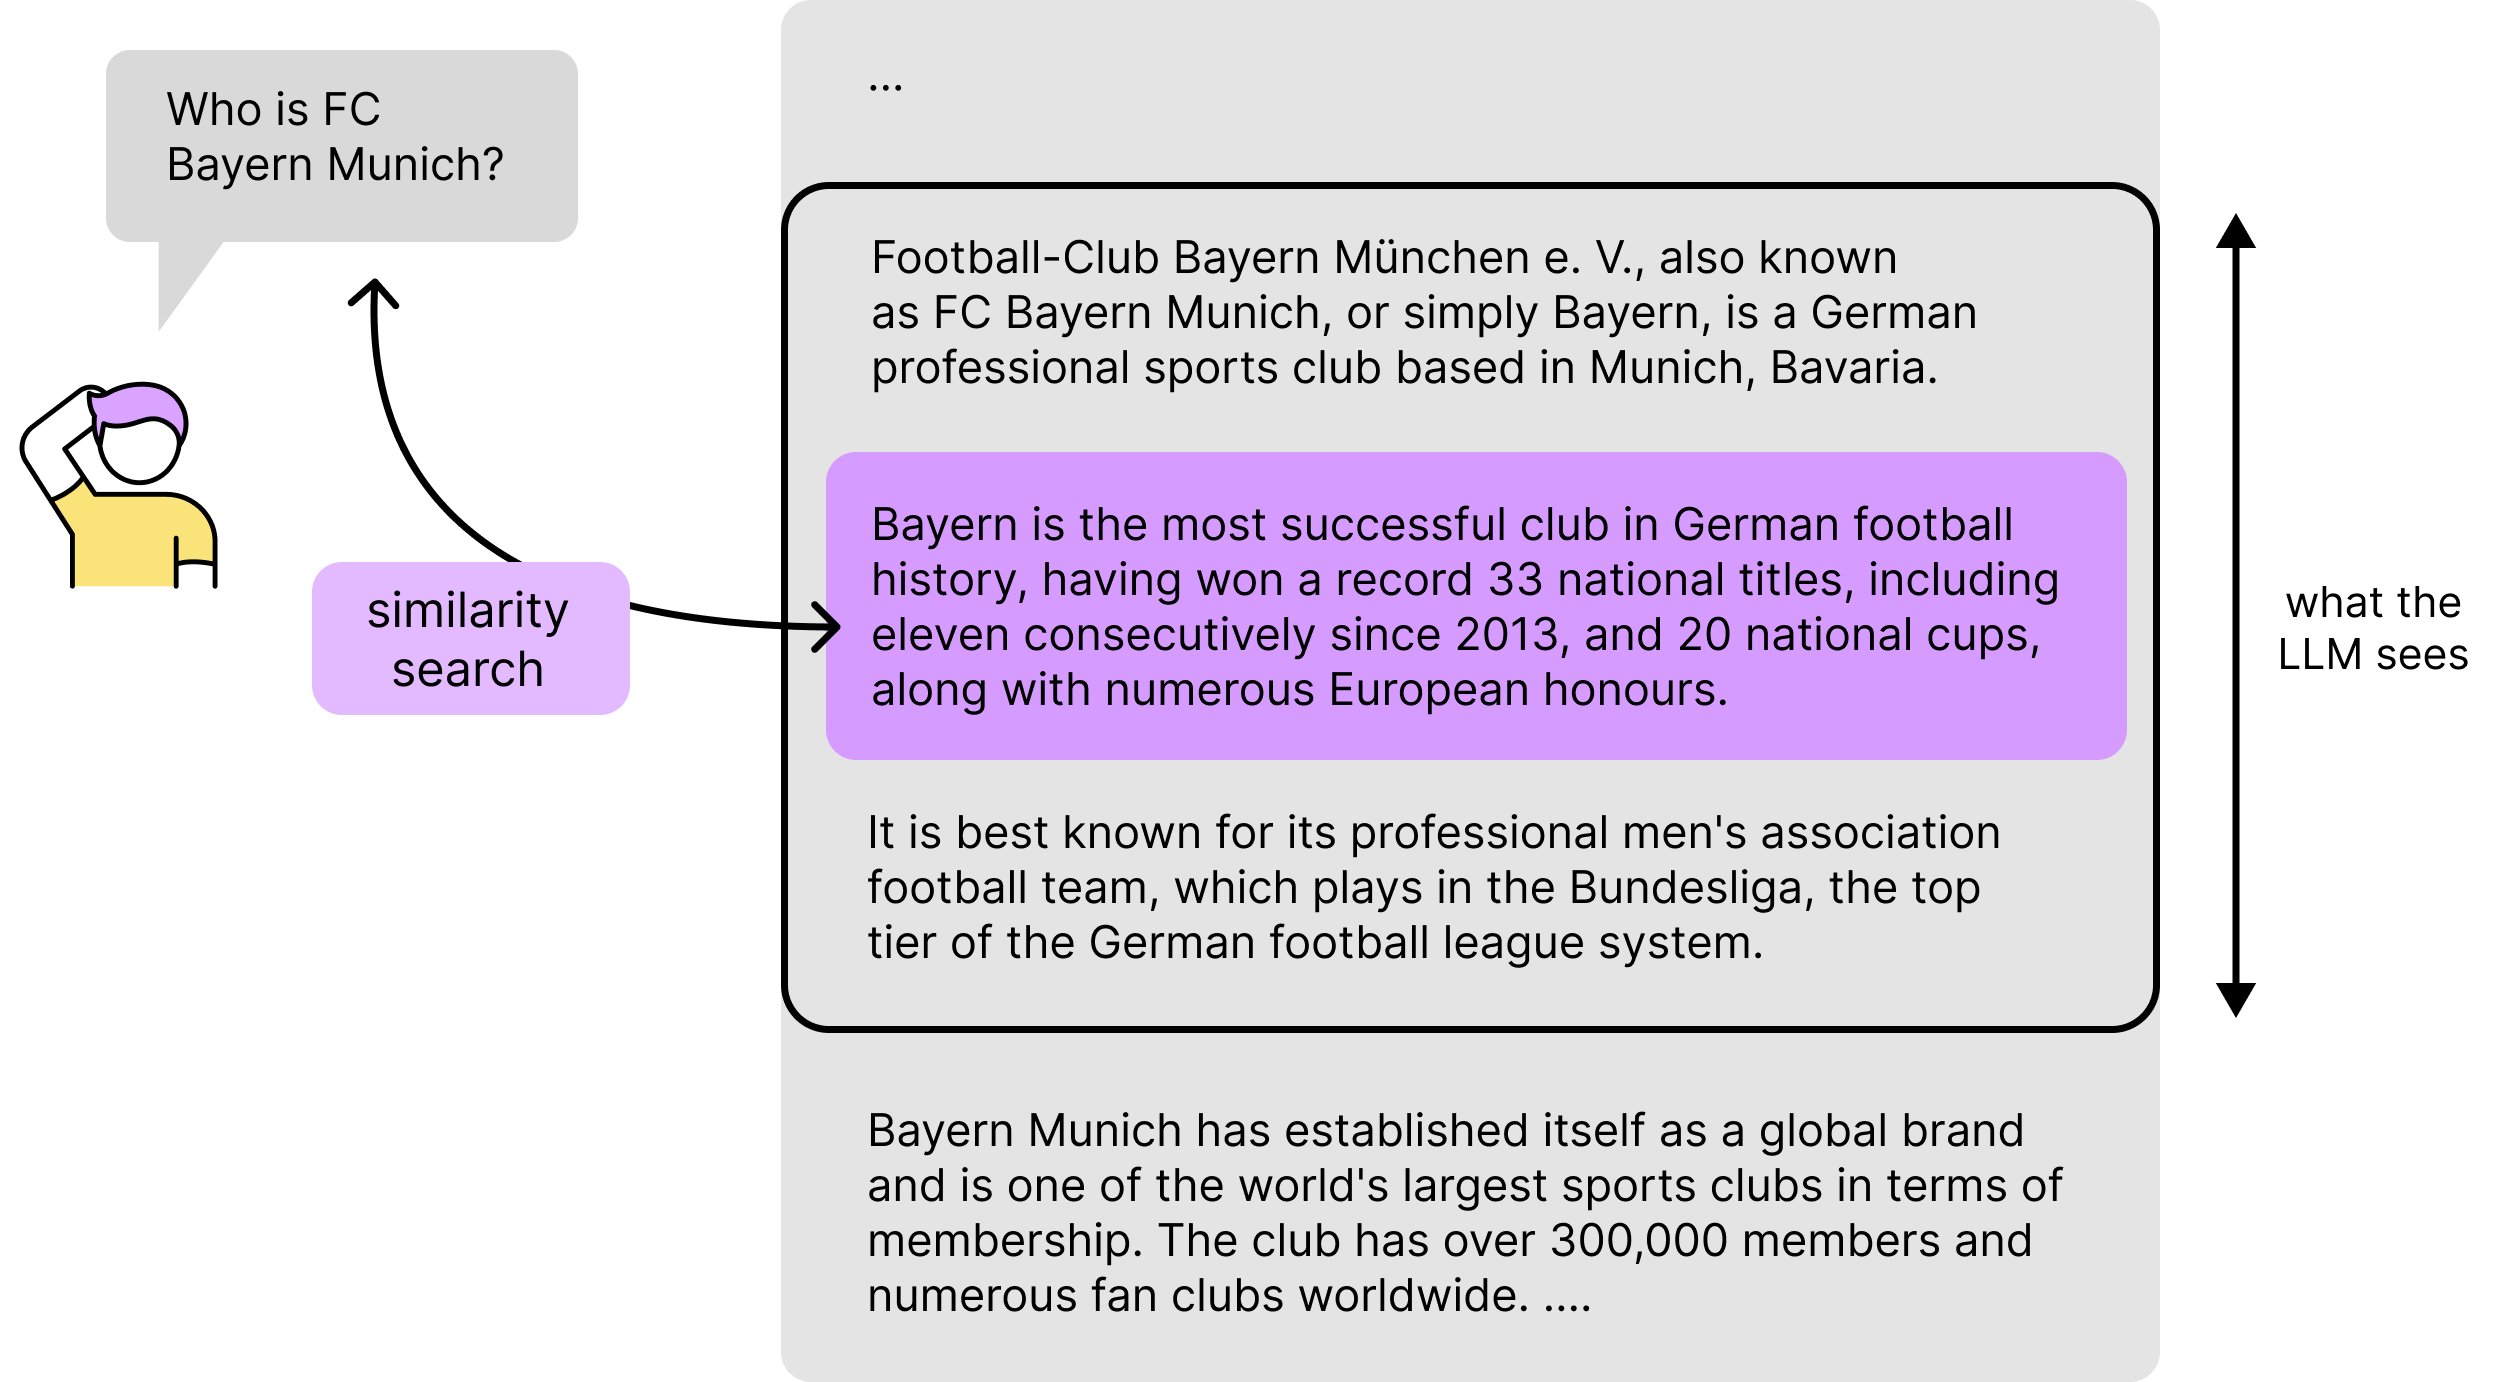

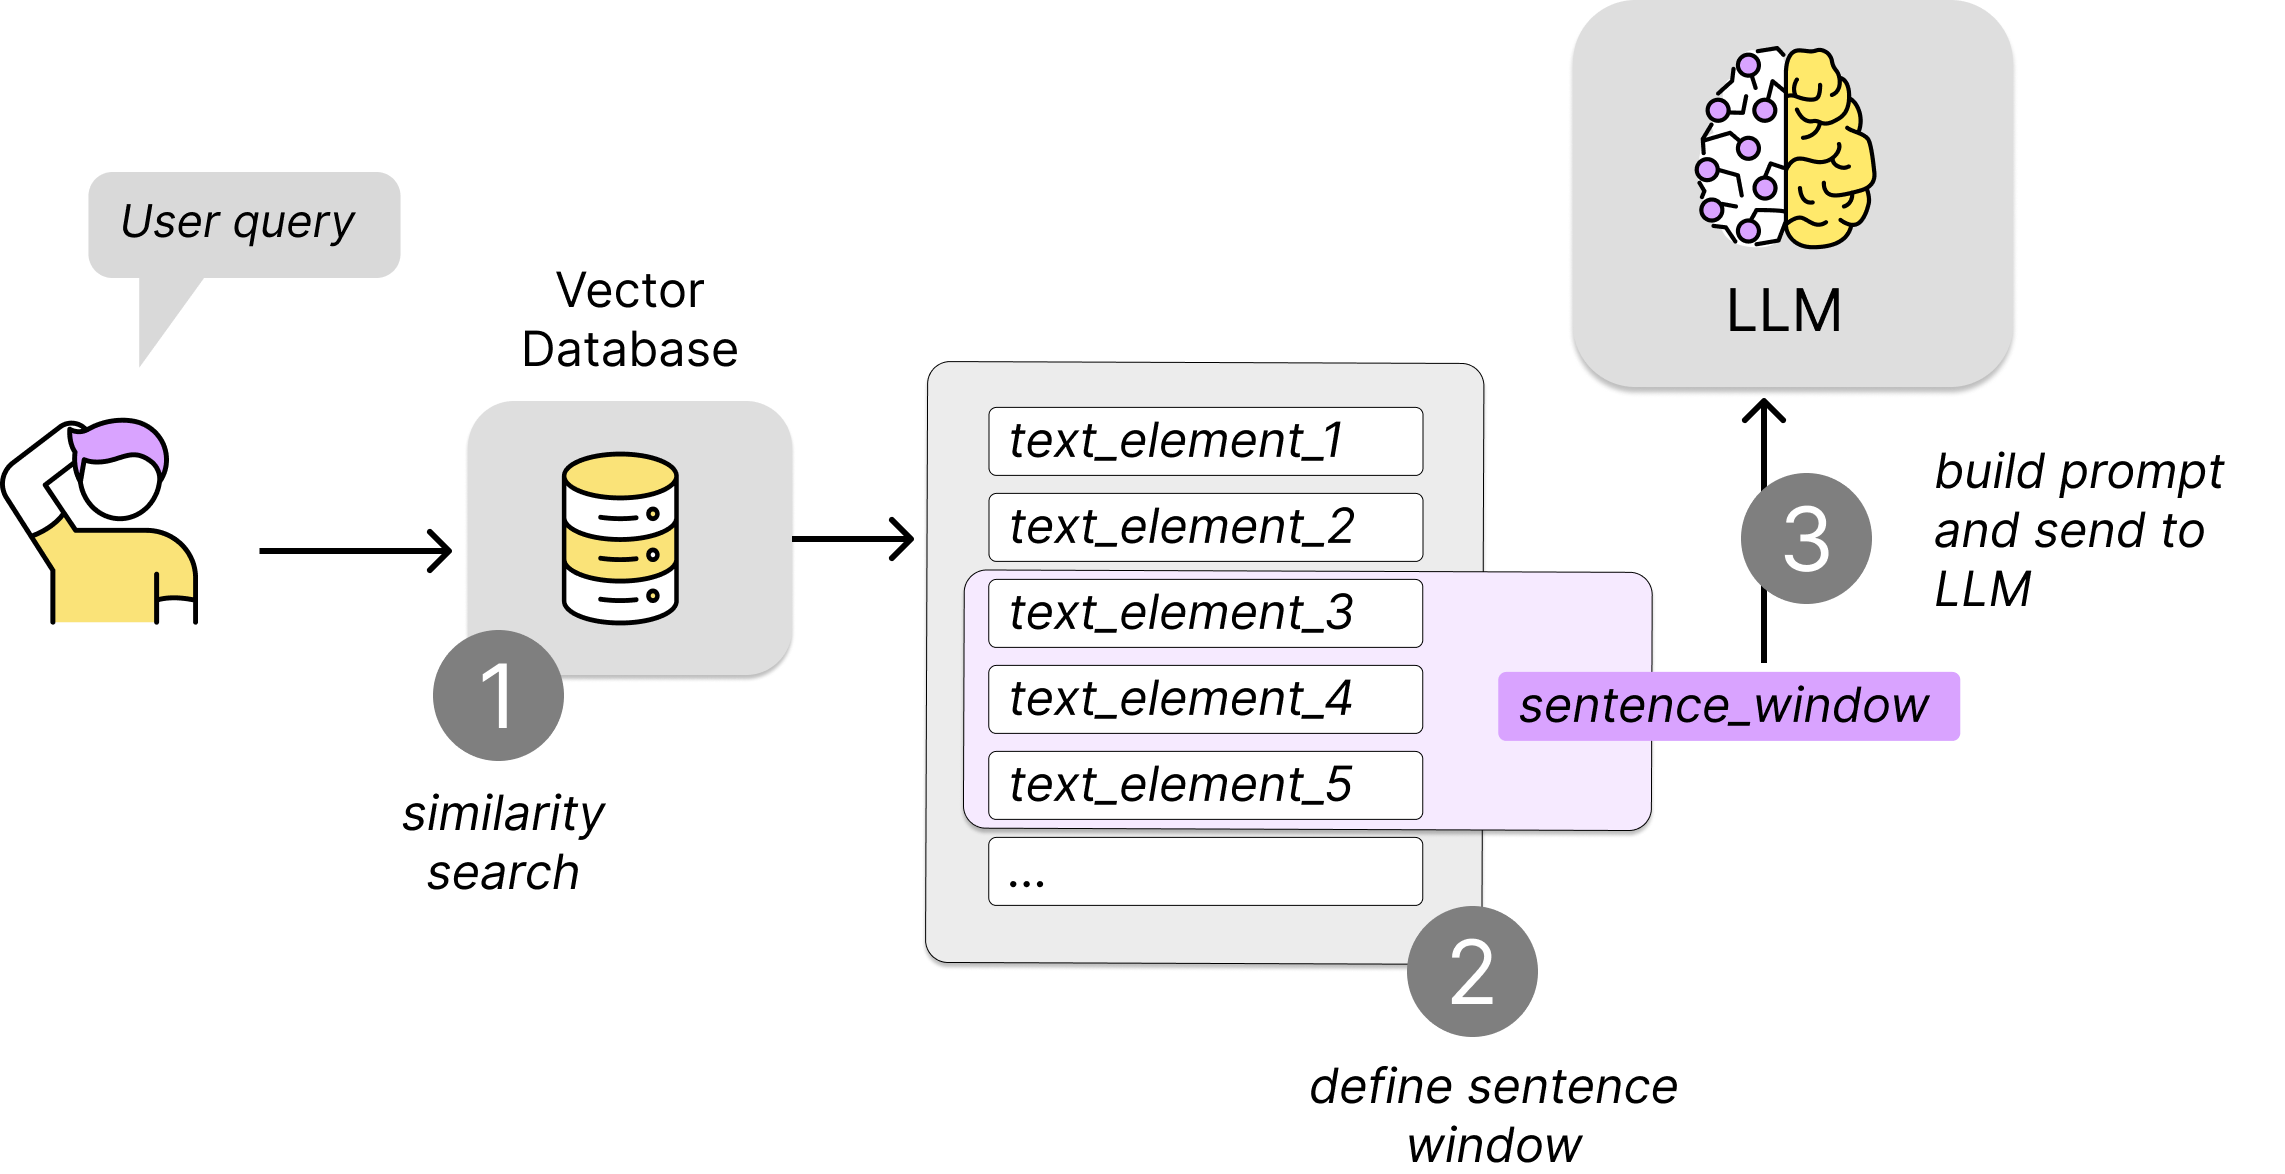

In [11]:
display(Image(filename="images/rwpc_0714.png", width=500, height=500))
display(Image(filename="images/rwpc_0715.png", width=500, height=500))

In [ ]:
# ------------------------------
# CREATE TABLE FOR SENTENCE/CHUNK EMBEDDINGS
# ------------------------------
# Table schema:
# - chunk_id: SERIAL PRIMARY KEY, auto-incremented ID for each chunk
# - chunk: the text of the sentence or window
# - chunk_embedding: 1536-dimensional vector for semantic similarity search

cur.execute(
    """
    CREATE TABLE sentence_window_retriever_text_chunks (
        chunk_id SERIAL PRIMARY KEY,
        chunk TEXT,
        chunk_embedding VECTOR(1536)
    )
"""
)

# Commit changes to the database
conn.commit()

# Sentence Window Retrieval: Practical Guidance

## How It Works
- Expand **retrieved chunks** by including **adjacent context** from the original document.  
- Mechanism:  
  1. Identify the **most relevant chunk** via semantic search.  
  2. Include **N chunks before and after** based on their position in the source document.  

---

## When to Use
- Your chunks are **small (200–500 tokens)** for retrieval precision.  
- **Adjacent context** is important for understanding (e.g., legal documents, technical manuals, narrative text).  
- Expanding by 1–2 chunks **doesn’t exceed your model’s context limit**.

## When to Skip
- Chunks are already **500+ tokens** with sufficient context.  
- Documents are **FAQ-style**, where each chunk is self-contained.  
- Evaluation metrics show **no improvement** from adding context.

---

## Trade-Offs
- **Prompt size vs. completeness**: expanding from 1,000 → 3,000 tokens triples context length, increasing cost and latency.  
- **Benefit**: reduces boundary effects where relevant information is split across chunk edges.

---

## Key Distinction
- **Sentence Window vs Auto-Merging**:  
  - Sentence window → fixed positional expansion (always add N adjacent chunks).  
  - Auto-merging → relevance-based expansion (merge parent only if multiple children match).  
- Use **sentence window** for straightforward positional context needs.  
- Use **auto-merging** when **document structure and relevance patterns** should drive expansion.

### 5.7 Improving Search Accuracy with Reranking Methods

# Reranking Retrieved Documents in RAG

## Problem
- Your system retrieves documents from **multiple sources or queries**, producing a large combined result set.  
- You need to **filter out the most relevant documents** to ensure the LLM sees high-quality context for generation.

---

## Solution
- **Merge and score results** from multiple retrieval methods:  
  - **HyDE** → generates multiple hypothetical documents and runs vector search per document.  
  - **Multi-query retrieval** → executes multiple reformulated queries in parallel.  
  - **Agent systems** → query multiple tools (SQL databases, vector stores, APIs, Python functions).  

- **Reranking step:**  
  1. Score all merged results based on **relevance to the user query**.  
  2. Keep only the **top items** for the LLM prompt.  
  3. Reduces **noise** and improves the **quality of generated answers**.

---

## Visualization (Figure 7-16)
- Combines multiple retrieved sets from different queries/tools.  
- Reranking assigns a **relevance score** to each document.  
- Only the **highest-scoring documents** are included in the final context.

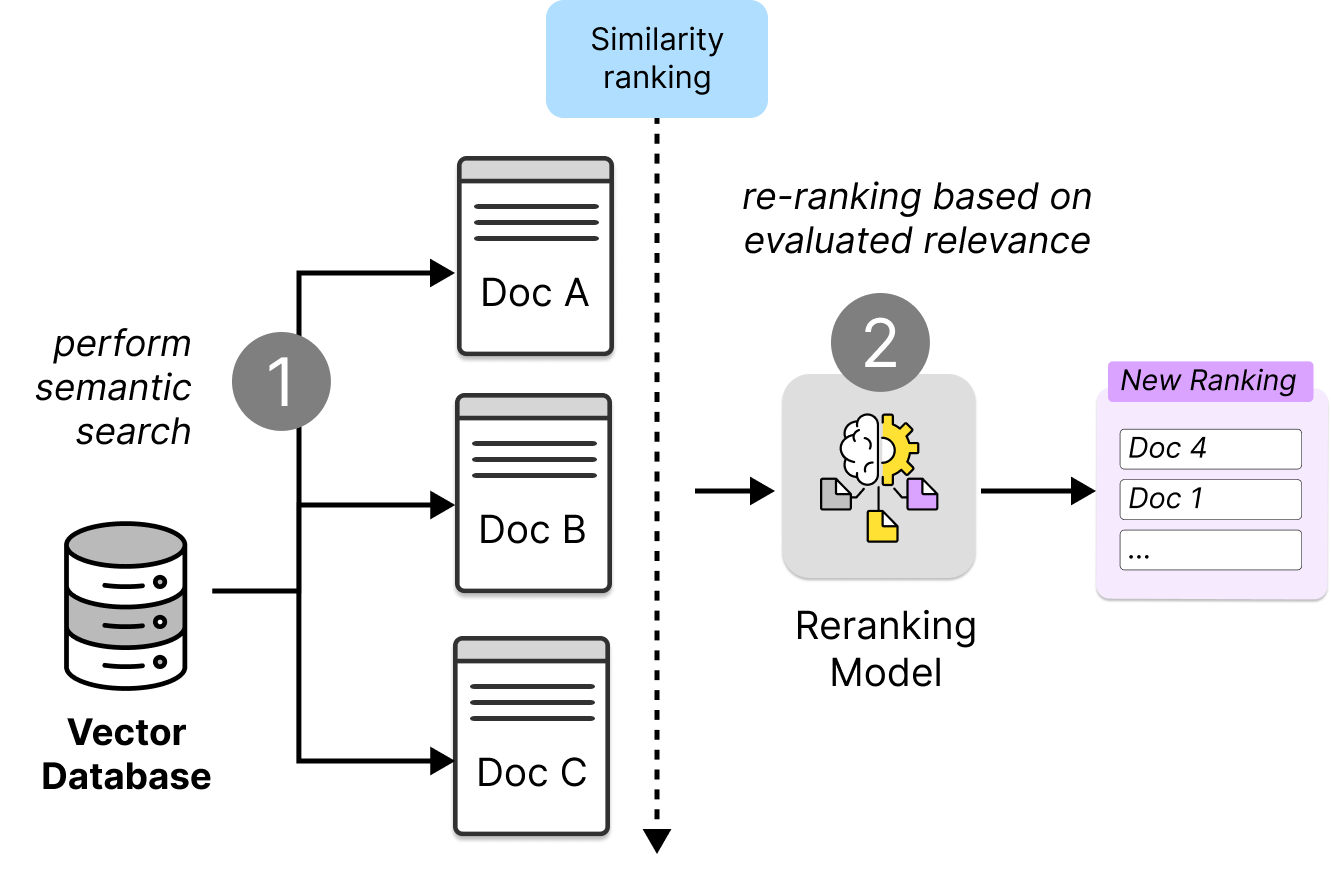

In [12]:
display(Image(filename="images/rwpc_0716.png", width=500, height=500))

In [ ]:
# ------------------------------
# IMPORT LIBRARIES
# ------------------------------
from pydantic import BaseModel, Field
from typing import Literal
from openai import OpenAI

# ------------------------------
# INITIALIZE OPENAI CLIENT
# ------------------------------
client = OpenAI()

# ------------------------------
# DEFINE USER QUERIES
# ------------------------------
# Each query initially has no selected data source
user_queries = [
    {"query": "Who is the all-time top scorer in the FIFA World Cup?", "selected_data_source": None},
    {"query": "What are the four Grand Slam tennis tournaments?", "selected_data_source": None},
    {"query": "Did Manchester United win their last game?", "selected_data_source": None},
]

# ------------------------------
# CREATE SYSTEM PROMPT FOR ROUTING
# ------------------------------
prompt = f"""
You are an expert at routing a user question to the appropriate
data source. Given a user question choose which of the data sources
in list_of_data_sources is the best to answer the question.
"""

# ------------------------------
# DEFINE RESPONSE FORMAT USING Pydantic
# ------------------------------
# Only allow one of the predefined data sources
class RouterDecision(BaseModel):
    data_source: Literal[
        "general_football_knowledge",
        "general_tennis_knowledge",
        "latest_football_results_sql",
    ] = Field(
        ...,
        description="The best data source to answer the question."
    )

# ------------------------------
# ROUTE EACH QUERY
# ------------------------------
for user_query in user_queries:
    completion = client.beta.chat.completions.parse(
        messages=[
            {"role": "system", "content": prompt},   # instructions for AI
            {"role": "user", "content": user_query["query"]},  # user query
        ],
        model="gpt-5-mini",
        response_format=RouterDecision,  # structured output
    )
    
    # Save the selected data source for this query
    user_query["selected_data_source"] = completion.choices[0].message.parsed.data_source

# ------------------------------
# REVIEW ROUTED QUERIES
# ------------------------------
user_queries

ParsedChatCompletion[RouterDecision](id='chatcmpl-DCAzutVrrjShSXg4bMt8efdQhBg34', choices=[ParsedChoice[RouterDecision](finish_reason='stop', index=0, logprobs=None, message=ParsedChatCompletionMessage[RouterDecision](content='{"data_source":"latest_football_results_sql"}', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None, parsed=RouterDecision(data_source='latest_football_results_sql')))], created=1771794582, model='gpt-5-mini-2025-08-07', object='chat.completion', service_tier='default', system_fingerprint=None, usage=CompletionUsage(completion_tokens=87, prompt_tokens=126, total_tokens=213, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=64, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))

# Reranking: Practical Guidance

## How It Works
- Scores and **filters merged retrieval results** before generation.  
- Keeps only the **top-K most relevant items** for the LLM prompt.  

---

## When to Use
- Combining **20+ candidates** from different sources.  
- Initial retrieval is **noisy** with many marginally relevant results.  
- Filtering to **top-5 after reranking** improves answer quality versus taking top-5 from each source.

## When to Skip
- You have a **single retrieval source** with good native ranking.  
- Retrieval already returns **highly relevant results**.  
- Added LLM call or cross-encoder cost isn’t justified by precision@K metrics.

---

## Trade-Offs
- **Latency and cost vs. relevance**:  
  - LLM-based reranking → adds one inference call for all candidates.  
  - Cross-encoder models → faster but still add overhead.  
- Benefit → more **relevant final results**, confidently filtering 50+ candidates down to 5–10 high-quality items.

---

## Key Distinction
- **Initial retrieval scoring**: fast, uses cosine similarity or BM25, treats query and document independently.  
- **Reranking**: uses cross-attention between query and candidates for deeper relevance assessment.  
- Use **two-stage approach**: initial retrieval for speed + reranking for accuracy.

### 5.8 Decomposing Complex Queries into Multiple Sub-Queries

# Query Decomposition in RAG

## Problem
- You want to **answer complex questions** by breaking them down into **simpler, manageable sub-questions**.

---

## Solution
- **End-to-end process (Figure 7-18):**  
  1. Break the **complex query** into simpler subqueries.  
  2. Trigger a **retrieval step** for each subquery.  
  3. Use the retrieved context to **generate answers** for each subquery.  
  4. **Combine all answers** in a final reasoning step to produce a comprehensive response.

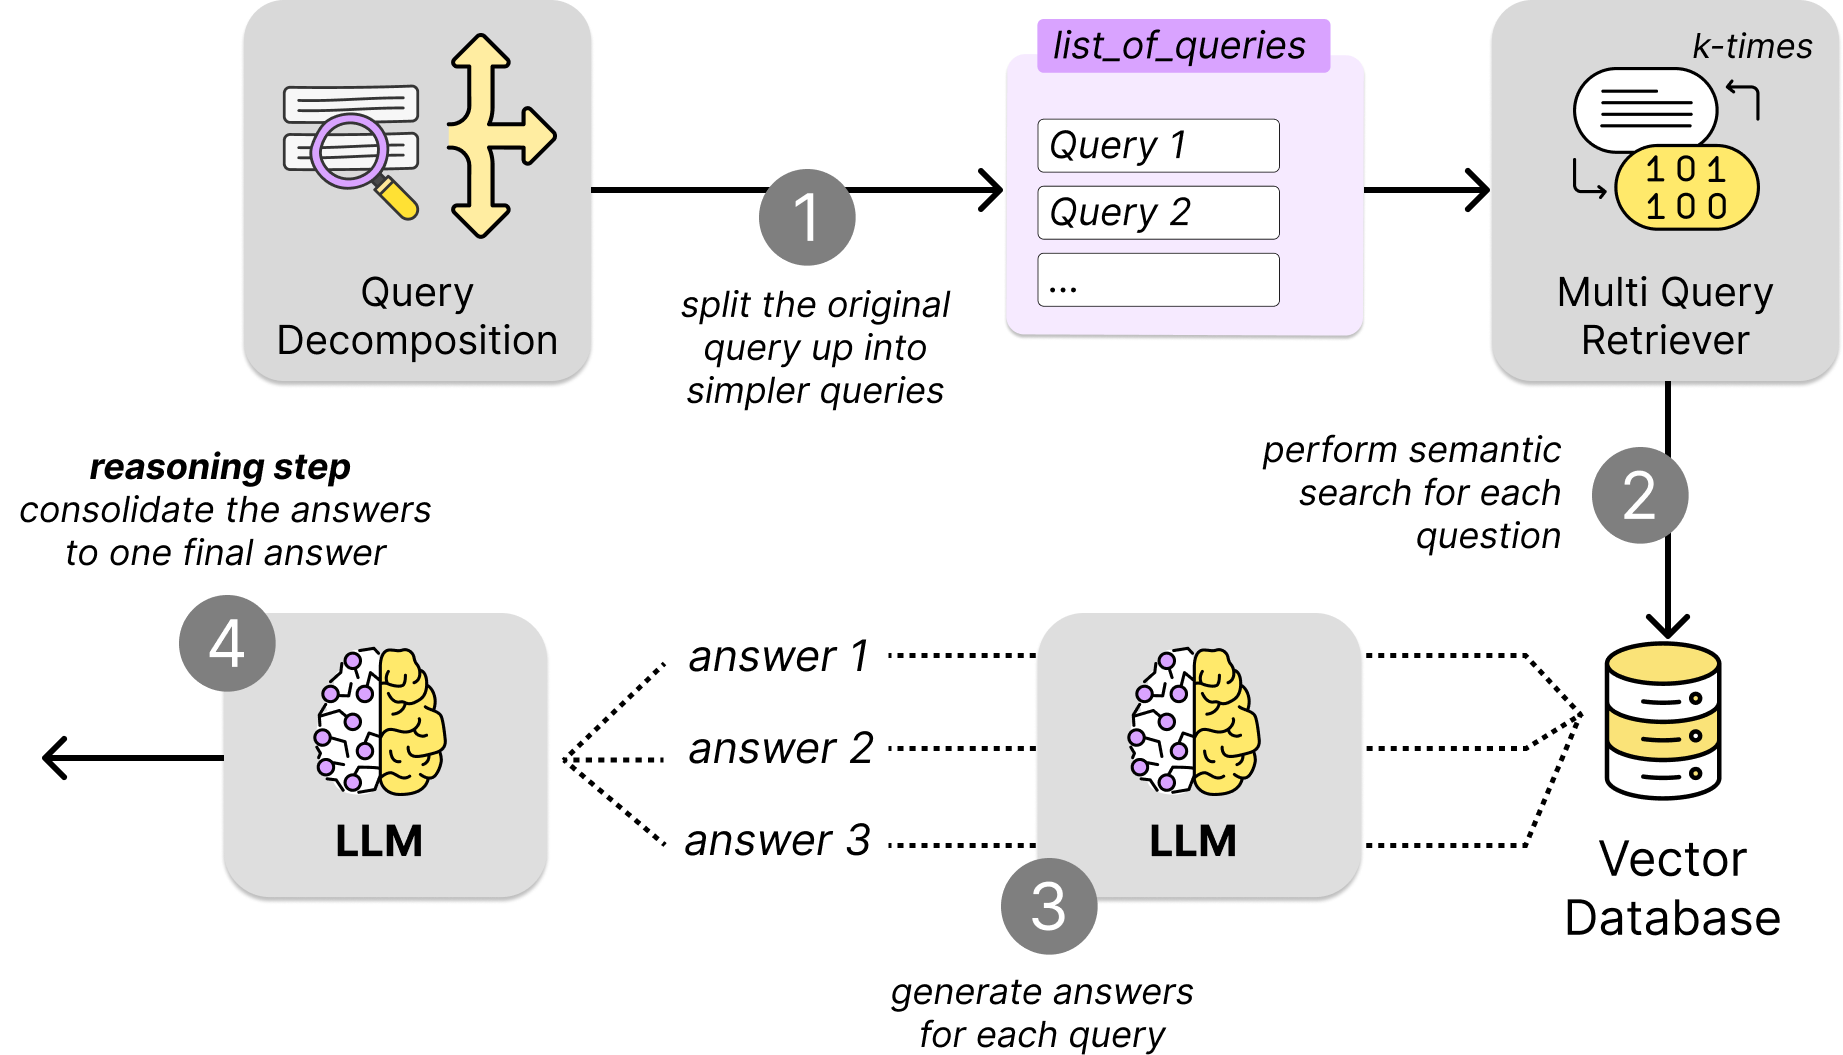

In [13]:
display(Image(filename="images/rwpc_0718.png", width=500, height=500))

In [ ]:
# ------------------------------
# IMPORT LIBRARIES
# ------------------------------
from pydantic import BaseModel
from typing import Optional
from openai import OpenAI

# ------------------------------
# DEFINE Pydantic MODELS
# ------------------------------
# Represents a single question with optional answer
class Question(BaseModel):
    question: str
    answer: Optional[str] = None

# Represents a list of questions
class Questions(BaseModel): 
    questions: list[Question]

# ------------------------------
# CREATE PROMPT FOR QUESTION DECOMPOSITION
# ------------------------------
splitter_prompt = """
You are a helpful assistant for a RAG chatbot.

Your job is to break down complex questions into simpler ones that 
are easy to answer. When the answers to these simpler questions are 
combined, they should fully answer the original question. If the 
question is already simple, leave it as it is. Handle one question 
at a time.

Example:
    1. Query: Did Microsoft or Google make more money last year?

Decomposed Questions:
    1. How much profit did Microsoft make last year?
    2. How much profit did Google make last year? 
"""

# ------------------------------
# INITIALIZE OPENAI CLIENT
# ------------------------------
client = OpenAI()

# ------------------------------
# DEFINE COMPLEX USER QUERY
# ------------------------------
query = (
    "What are the benefits of renewable energy compared to "
    "fossil fuels?"
)

# ------------------------------
# SEND PROMPT TO OPENAI FOR QUESTION DECOMPOSITION
# ------------------------------
completion = client.beta.chat.completions.parse(
    model="gpt-5-mini",
    messages=[
        {"role": "system", "content": splitter_prompt},  # instruction to decompose
        {"role": "user", "content": query},             # user query
    ],
    response_format=Questions,  # structured response containing list of questions
)

# ------------------------------
# EXTRACT DECOMPOSED QUESTIONS
# ------------------------------
decomposed_questions = completion.choices[0].message.parsed.questions

# Display the decomposed questions
decomposed_questions

[Question(question='How do greenhouse gas emissions from renewable energy compare to those from fossil fuels?', answer='Renewables (wind, solar, hydro) produce little to no operational CO2; their lifecycle emissions (manufacturing, installation, maintenance) are typically a small fraction of coal or natural gas—often an order of magnitude lower per kWh.'),
 Question(question='How does air pollution and public health differ between renewables and fossil fuels?', answer='Renewables emit negligible local air pollutants, while burning fossil fuels releases PM2.5, NOx, SO2 and other toxins that cause respiratory and cardiovascular disease and premature deaths.'),
 Question(question='Are renewable energy sources economically competitive with fossil fuels?', answer='Many renewables—especially onshore wind and utility-scale solar—have lower levelized costs than new fossil-fuel generation today; they have near-zero fuel costs, though integration and storage add system costs in high-penetration 

# Query Decomposition: Practical Guidance

## How It Works
- Breaks **complex questions** into simpler sub-questions.  
- Retrieves context for each sub-question **independently**.  
- Synthesizes **sub-answers** into a **final response**.

---

## When to Use
- Questions require **aggregating information from multiple sources** (“Compare X and Y”).  
- Breaking down the query makes **each sub-search more precise**.  
- Can **run subqueries in parallel** to limit latency.  
- Intermediate answers help **debug why the final answer may fail**.

## When to Skip
- Questions are **simple and direct** (“What is X?”).  
- Single retrieval provides **sufficient context**.  
- Added LLM calls (decomposition + final reasoning) make **latency unacceptable**.  
- Evaluation shows **single-step retrieval** performs equally well.

---

## Trade-Offs
- **Complexity and latency vs. completeness**:  
  - Adds **two LLM calls** (decomposition + synthesis) + multiple retrieval steps.  
  - Enables answering **questions no single retrieval can handle**, e.g., “Which company was more profitable: Microsoft or Google?”

## Key Distinction
- **Query decomposition vs. multi-query retrieval**:  
  - Decomposition → creates **distinct sub-questions** needing separate answers.  
  - Multi-query → creates **semantically similar variants** of one question to improve recall.  
  - Combine both for **complex multi-part questions** that benefit from multiple phrasings per sub-question.